## Import libraries

All required libraries are imported below:
- `scikit-learn` for preprocessing pipelines and the Random Forest baseline
- `xgboost` for the gradient-boosted model
- `optuna` for Bayesian hyperparameter search (more sample-efficient than grid search)
- `shap` for model-agnostic explainability via TreeSHAP
- `networkx` for graph construction and centrality computation
- `matplotlib` / `seaborn` for visualisation

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

from xgboost import XGBRegressor
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import shap

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import networkx as nx

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# plot aesthetic 
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.0f}".format)

## Data loading

**Load dataset**

In [ ]:
df = pd.read_parquet("/Users/tuongminh/Desktop/thesis/eurostar/data/processed/survey_and_operational_data.parquet")

print(df.shape)
df.head()

In [8]:
dtype_summary = df.dtypes.astype(str).value_counts().rename('count').to_frame()
dtype_summary.index.name = 'dtype'
print("Column counts by dtype:")
print(dtype_summary.to_string())

Column counts by dtype:
                     count
dtype                     
Int8                    98
float64                 47
object                  45
int64                   19
datetime64[us, UTC]      2


## NPS Explore

**NPS Distribution**

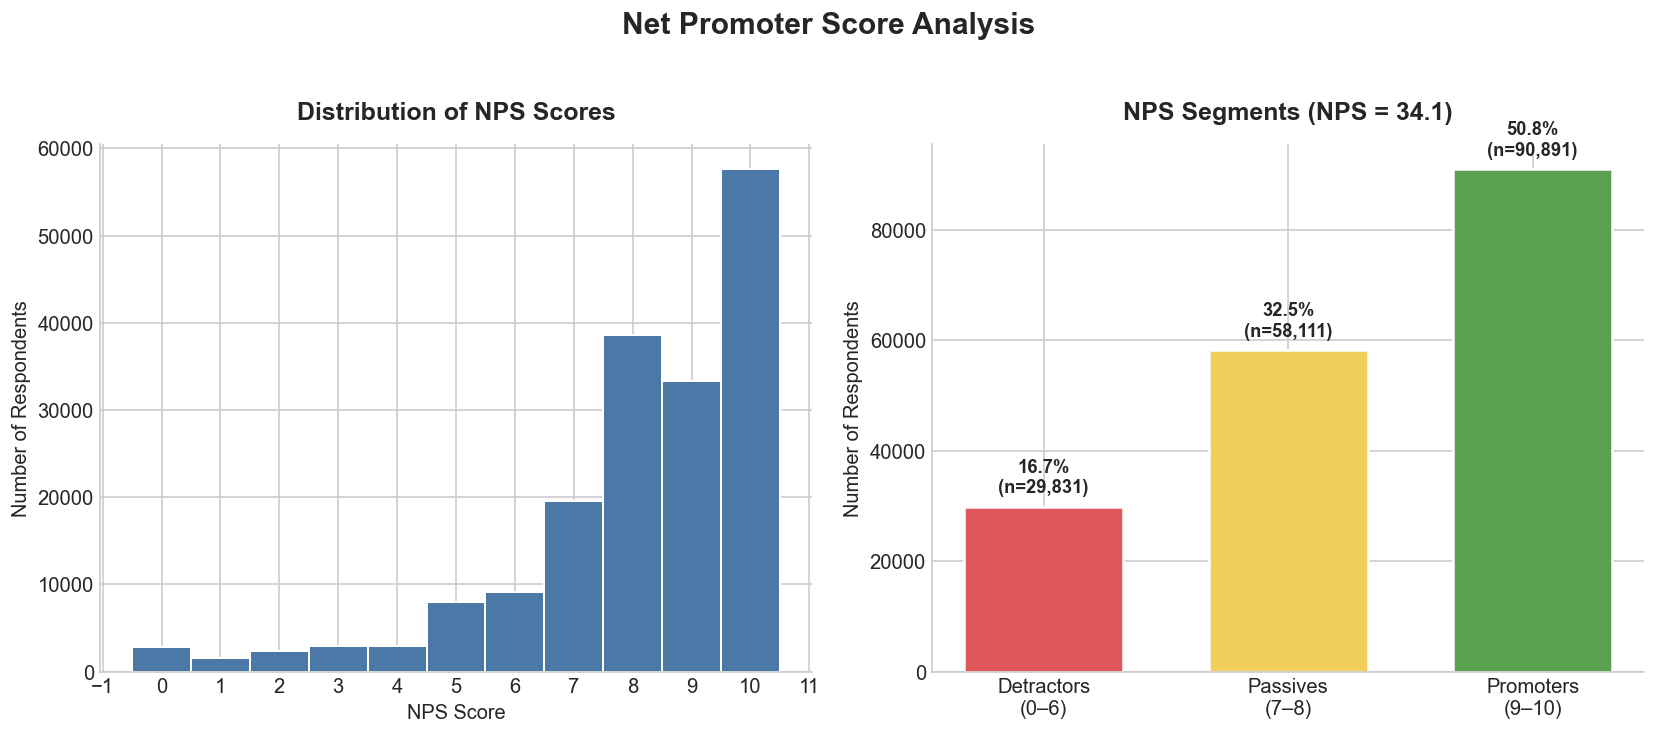

Net NPS: 34.1
Promoters (9-10): 90,891 (50.8%)
Passives (7-8): 58,111 (32.5%)
Detractors (0-6): 29,831 (16.7%)


In [ ]:
TARGET = 'metadata_recommendation_nps_a'
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(
    df[TARGET],
    bins=np.arange(-0.5, 11.5, 1),
    color='#4C78A8',
    edgecolor='white',
    linewidth=1.2
)

axes[0].set_title(
    'Distribution of NPS Scores',
    fontsize=15,
    fontweight='bold',
    pad=15
)
axes[0].set_xlabel('NPS Score', fontsize=12)
axes[0].set_ylabel('Number of Respondents', fontsize=12)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

nps_vals = df[TARGET]

detractors = (nps_vals <= 6).sum()
passives = ((nps_vals >= 7) & (nps_vals <= 8)).sum()
promoters = (nps_vals >= 9).sum()

total = len(nps_vals)
nps_score = round((promoters - detractors) / total * 100, 1)

segments = [detractors, passives, promoters]
labels = [
    'Detractors\n(0–6)',
    'Passives\n(7–8)',
    'Promoters\n(9–10)'
]

colors = ['#E15759', '#F2CF5B', '#59A14F']

bars = axes[1].bar(
    labels,
    segments,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.65
)

for bar, value in zip(bars, segments):
    pct = value / total * 100
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        value + total*0.01,
        f'{pct:.1f}%\n(n={value:,})',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='semibold'
    )

axes[1].set_title(
    f'NPS Segments (NPS = {nps_score})',
    fontsize=15,
    fontweight='bold',
    pad=15
)

axes[1].set_ylabel('Number of Respondents', fontsize=12)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle(
    'Net Promoter Score Analysis',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

print (f'Net NPS: {nps_score}')
print (f'Promoters (9-10): {promoters:,} ({promoters/total:.1%})')
print (f'Passives (7-8): {passives:,} ({passives/total:.1%})')
print (f'Detractors (0-6): {detractors:,} ({detractors/total:.1%})')

**Group analysis**

In [10]:
# define groups
groups = {
    'Overall satisfaction': [c for c in df.columns if c.startswith ('question_overall_satisfaction')],
    'Lounge experience': [c for c in df.columns if c.startswith ('question_lounge_overall')],
    'On-board experience': [c for c in df.columns if c.startswith ('question_onboard') or c.startswith('question_on_board')],
    'Disruption': [c for c in df.columns if c.startswith ('question_disruption')],
    'Overall satisfaction': [c for c in df.columns if c.startswith ('question_overall_satisfaction')],
    'Station experience': [c for c in df.columns if c.startswith ('question_at_the_station')],
    'Arrival experience': [c for c in df.columns if c.startswith ('question_arrival')],
    'Staff & service': [c for c in df.columns if c.startswith ('question_staff') or c.startswith('question_service')],
}

rows = []
for group, cols in groups.items():
    num_cols = [c for c in cols if df[c].dtype in ['Int8', 'int64', 'float64'] or str(df[c].dtype).startswith('int')]
    if not num_cols:
        continue
    sub = df[num_cols].apply (pd.to_numeric, errors = 'coerce')
    rows.append ({
        'Group': group,
        'Columns': len(num_cols),
        'Average response rate': f'{(1 - sub.isnull().mean().mean()) * 100:.1f}%',
        'Mean score': f'{sub.stack().mean():.2f}',
        'Std dev': f'{sub.stack().std():.2f}'
    })

summary_df = pd.DataFrame(rows)
print (summary_df.to_string(index = False))

               Group  Columns Average response rate Mean score Std dev
Overall satisfaction        8                 95.9%       4.01    1.19
   Lounge experience       12                  2.1%       3.88    1.14
 On-board experience       20                 13.6%       3.94    1.06
          Disruption       12                 13.5%       3.23    1.29
  Station experience        9                 19.5%       3.74    1.17
  Arrival experience        4                 14.1%       4.11    0.96
     Staff & service       13                 31.9%       4.10    0.94


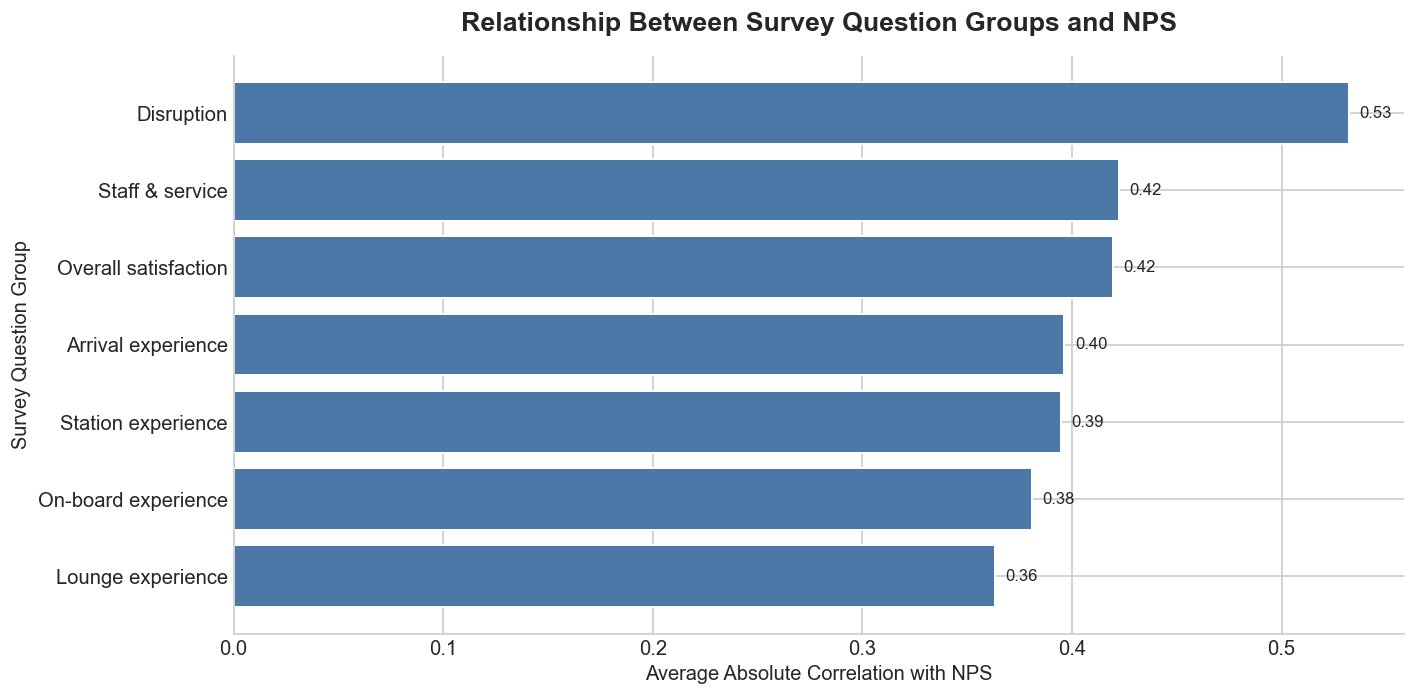

In [11]:
# correlation of survey question groups with NPS
corr_data = {}

for group, cols in groups.items():
    num_cols = [
        c for c in cols
        if str(df[c].dtype) in ['Int8', 'Int16', 'Int32', 'Int64',
                                'int64', 'float64']
    ]

    if not num_cols:
        continue

    sub = df[num_cols].apply(pd.to_numeric, errors='coerce')

    corr_data[group] = (
        sub.corrwith(df[TARGET].astype(float))
        .abs()
        .mean()
    )

corr_series = pd.Series(corr_data).sort_values(ascending=True)

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    corr_series.index,
    corr_series.values,
    color='#4C78A8',
    edgecolor='white',
    linewidth=1.2
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        fontsize=10
    )

ax.set_title(
    'Relationship Between Survey Question Groups and NPS',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Average Absolute Correlation with NPS',
    fontsize=12
)

ax.set_ylabel('Survey Question Group', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**NPS by route and class of service**

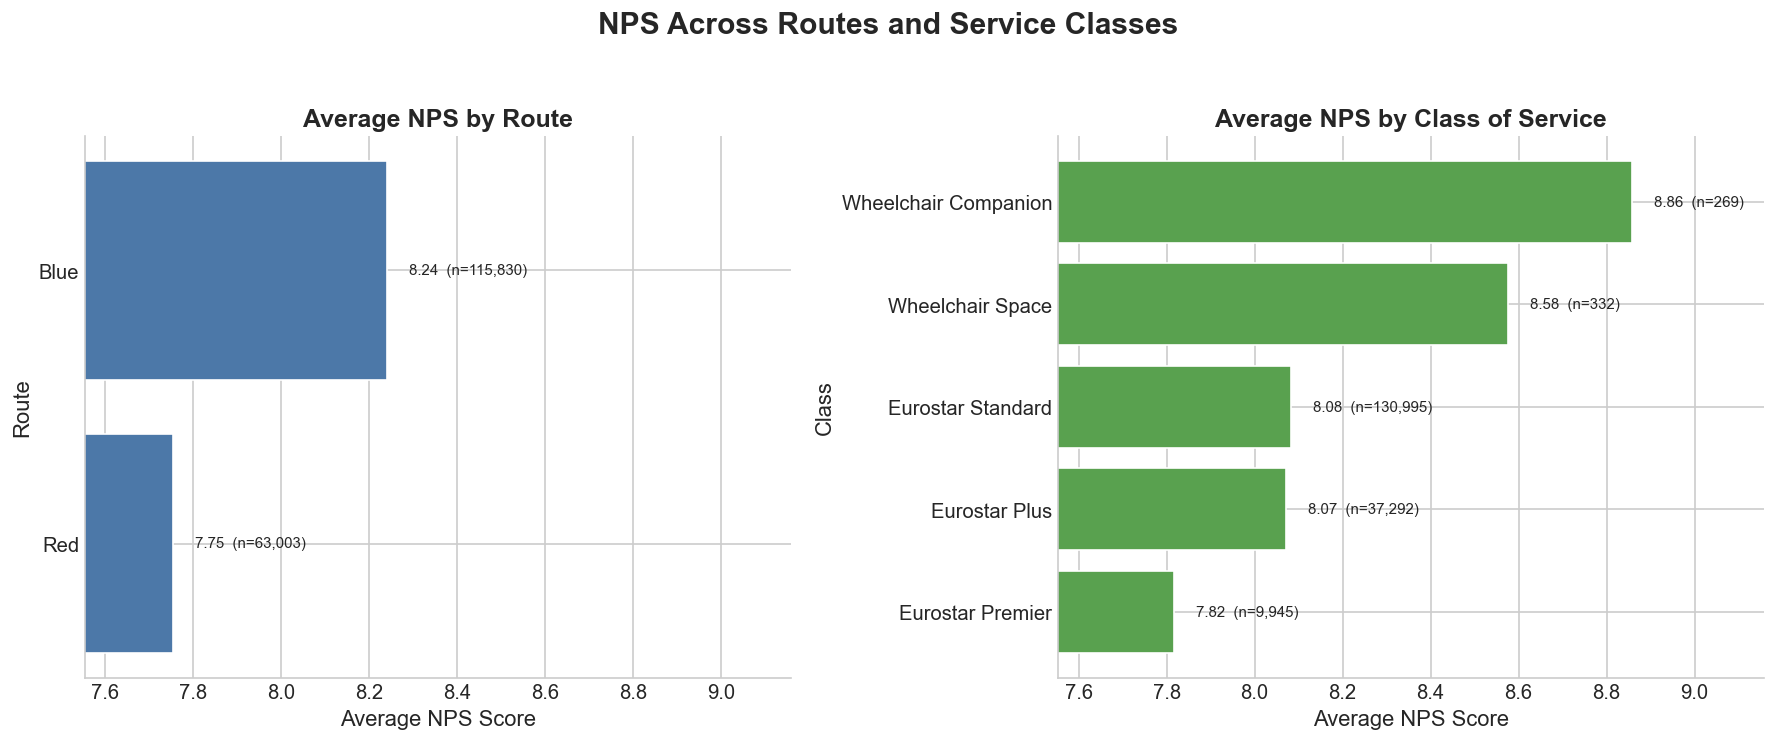

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


route_nps = (
    df.groupby('metadata_route')[TARGET]
      .agg(['mean', 'count'])
      .reset_index()
)

route_nps = (
    route_nps[route_nps['count'] > 100]
    .sort_values('mean')
)

bars = axes[0].barh(
    route_nps['metadata_route'],
    route_nps['mean'],
    color='#4C78A8',
    edgecolor='white',
    linewidth=1
)

for i, (_, row) in enumerate(route_nps.iterrows()):
    axes[0].text(
        row['mean'] + 0.05,
        i,
        f"{row['mean']:.2f}  (n={row['count']:,})",
        va='center',
        fontsize=9
    )

axes[0].set_title(
    'Average NPS by Route',
    fontsize=15,
    fontweight='bold'
)

axes[0].set_xlabel('Average NPS Score')
axes[0].set_ylabel('Route')

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

class_nps = (
    df.groupby('metadata_class_of_service')[TARGET]
      .agg(['mean', 'count'])
      .reset_index()
)

class_nps = (
    class_nps[class_nps['count'] > 100]
    .sort_values('mean')
)

bars = axes[1].barh(
    class_nps['metadata_class_of_service'],
    class_nps['mean'],
    color='#59A14F',
    edgecolor='white',
    linewidth=1
)

for i, (_, row) in enumerate(class_nps.iterrows()):
    axes[1].text(
        row['mean'] + 0.05,
        i,
        f"{row['mean']:.2f}  (n={row['count']:,})",
        va='center',
        fontsize=9
    )

axes[1].set_title(
    'Average NPS by Class of Service',
    fontsize=15,
    fontweight='bold'
)

axes[1].set_xlabel('Average NPS Score')
axes[1].set_ylabel('Class')

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# use same scale for easier comparison
xmin = min(route_nps['mean'].min(), class_nps['mean'].min()) - 0.2
xmax = max(route_nps['mean'].max(), class_nps['mean'].max()) + 0.3

axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)

fig.suptitle(
    'NPS Across Routes and Service Classes',
    fontsize=18,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()
plt.show()

**NPS by delay**

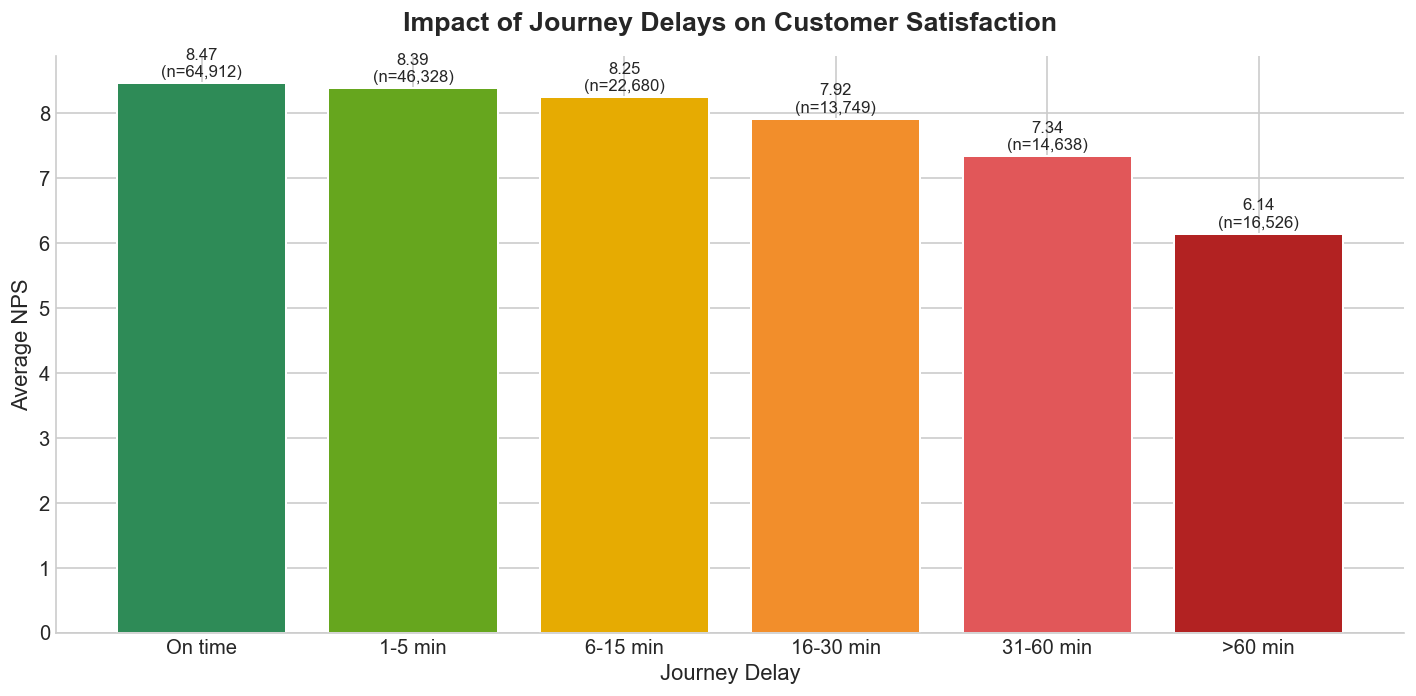

In [ ]:
# calculate mean NPS and sample size
df['total_delay'] = ( pd.to_numeric(df['arrival_delay_minute'], errors='coerce').fillna(0) + 
                     pd.to_numeric(df['early_journey_delay_minute'], errors='coerce').fillna(0) ) 
df['delay_band'] = pd.cut (df['total_delay'].clip (0, 120), bins = [-1, 0, 5, 15, 30, 60, 120], labels = ['On time', '1-5 min', '6-15 min', '16-30 min', '31-60 min', '>60 min'])
delay_summary = (
    df.groupby('delay_band', observed=True)[TARGET]
      .agg(['mean', 'count'])
      .reset_index()
)

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 6))

colors = [
    '#2E8B57',  
    '#66A61E',
    '#E6AB02',
    '#F28E2B',
    '#E15759',
    '#B22222'   
]

bars = ax.bar(
    delay_summary['delay_band'],
    delay_summary['mean'],
    color=colors,
    edgecolor='white',
    linewidth=1.2
)

for bar, (_, row) in zip(bars, delay_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        row['mean'] + 0.1,
        f"{row['mean']:.2f}\n(n={row['count']:,})",
        ha='center',
        fontsize=10
    )

ax.set_title(
    'Impact of Journey Delays on Customer Satisfaction',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Journey Delay')
ax.set_ylabel('Average NPS')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

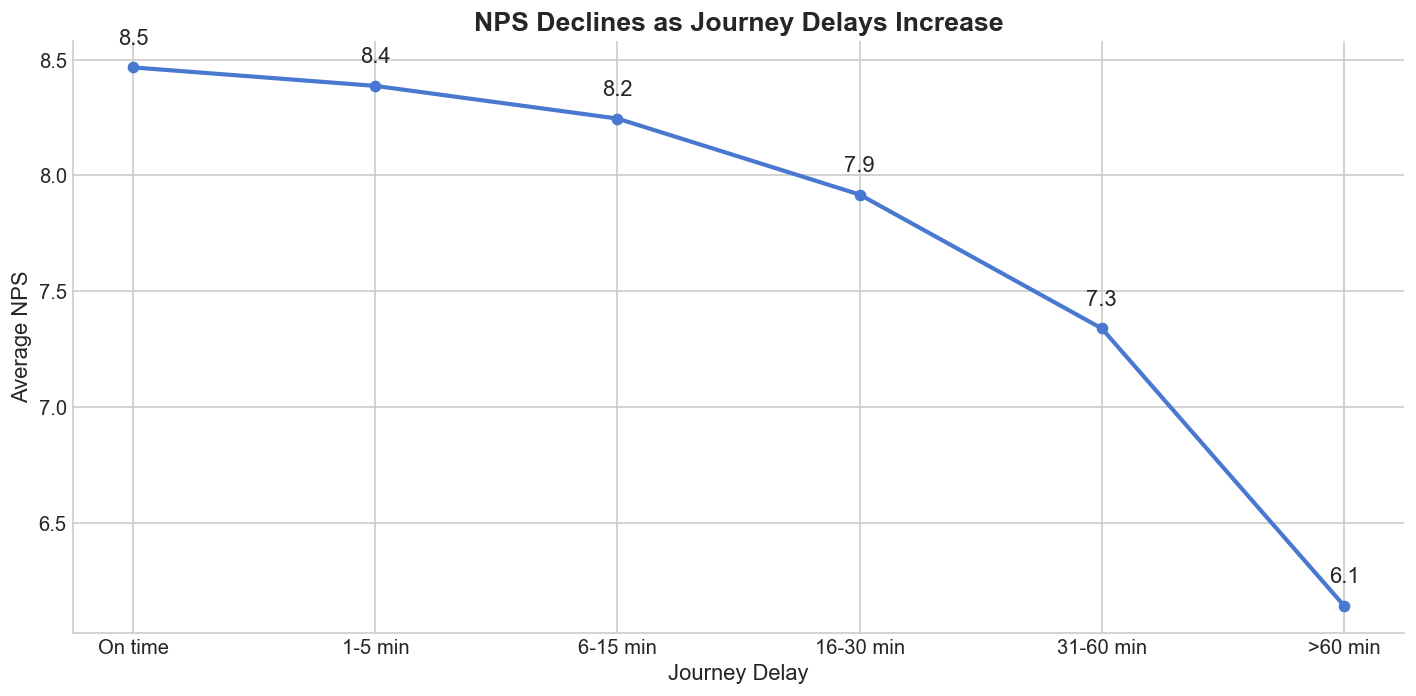

In [14]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    delay_summary['delay_band'],
    delay_summary['mean'],
    marker='o',
    linewidth=2.5
)

for x, y in zip(delay_summary['delay_band'], delay_summary['mean']):
    ax.text(x, y + 0.1, f'{y:.1f}', ha='center')

ax.set_title(
    'NPS Declines as Journey Delays Increase',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Journey Delay')
ax.set_ylabel('Average NPS')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Feature engineering & Preprocessing

**Define target**

In [15]:
y = df[TARGET].copy()
X = df.drop(columns = [TARGET])

**Remove leakage**

In [16]:
leakage_columns = [
    'question_qid61_nps_group',
    'metadata_booking_date',
    'metadata_departure_date',
    'metadata_end_date',
    'metadata_start_date',
    'service_id',
    'trainset',
    'question_overall_rating',
    'question_future_consideration'
]

X = X.drop(columns = leakage_columns)

In [17]:
# drop the previous total delay column
if 'total_delay' in X.columns:
    X = X.drop(columns = ['total_delay'])

X = X.drop (columns = 'delay_band')

print (f'Feature matrix: {X.shape[0]:,} row x {X.shape[1]} columns')
print (f'Dropped leakage columns: {leakage_columns}')

Feature matrix: 178,833 row x 201 columns
Dropped leakage columns: ['question_qid61_nps_group', 'metadata_booking_date', 'metadata_departure_date', 'metadata_end_date', 'metadata_start_date', 'service_id', 'trainset', 'question_overall_rating', 'question_future_consideration']


**Identify feature types**

In [19]:
categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=['int64', 'float64', 'Int8', 'Int16', 'Int32', 'Int64']
).columns.tolist()

datetime_cols = X.select_dtypes(
    include=['datetime64[ns, UTC]', 'datetime64']
).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in datetime_cols]
X = X.drop(columns=datetime_cols)

print(f'Numeric features: {len(numeric_cols)}')
print(f'Categorical features: {len(categorical_cols)}')
print(f'Datetime cols dropped: {datetime_cols}')

Numeric features: 162
Categorical features: 37
Datetime cols dropped: ['origin_theoretical_time', 'destination_theoretical_time']


In [ ]:
print (f'Dataset: {X.shape[0]:,} row x {X.shape[1]} columns')
X.head()

**Preprocessing pipeline**

In [21]:
numeric_transformer = Pipeline ([
    ('imputer', SimpleImputer (strategy = 'median'))
])

categorical_transformer = Pipeline ([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder (handle_unknown='infrequent_if_exist', max_categories=20, sparse_output=True))
])

preprocessor = ColumnTransformer (
    transformers = [
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

print ('Preprocessing pipeline defined')
print (f'Numeric path: median imputation')
print (f'Categorical path: mode imputation -> OneHotEncoder')

Preprocessing pipeline defined
Numeric path: median imputation
Categorical path: mode imputation -> OneHotEncoder


**Train test split**

In [22]:
y_bin = pd.cut (y, bins = [-1, 6, 8, 10], labels = ['detractor', 'passive', 'promoter'])

X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify=y_bin
)

print (f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print (f'Train NPS mean: {y_train.mean():.3f}| Test NPS mean: {y_test.mean():.3f}')
print (f'Train NPS std {y_train.std():.3f} | Test NPS std: {y_test.std():.3f}')

Train: 143,066 rows | Test: 35,767 rows
Train NPS mean: 8.070| Test NPS mean: 8.061
Train NPS std 2.183 | Test NPS std: 2.202


## Random forest baseline

In [23]:
rf_pipeline = Pipeline ([
    ('prep', preprocessor),
    ('model', RandomForestRegressor (
        n_estimators=200,
        max_features = 'sqrt',
        min_samples_leaf = 5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print ('Fitting the model')
rf_pipeline.fit(X_train,y_train)
rf_pred = rf_pipeline.predict(X_test)
print ('Done!')

Fitting the model
Done!


**Evaluate RF**

- MAE: average prediction error in NPS
- RMSE: penalizes large errors more heavily & sensitive to outliers
- R^2: proportion of variance explained

In [24]:
def evaluate (name, y_true, y_pred):
    mae = mean_absolute_error (y_true, y_pred)
    rmse = np.sqrt (mean_squared_error (y_true, y_pred))
    r2 = r2_score (y_true, y_pred)
    print ('-'*40)
    print (name)
    print ('-'*40)
    print (f'MAE: {mae:.4f} (avg error in NPS)')
    print (f'RMSE: {rmse:.4f}')
    print (f'R^2: {r2:.4f} ({r2*100:.1f}% of variance explained)')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2':r2}

results = []
results.append (evaluate ('Random Forest (baseline)', y_test, rf_pred))

----------------------------------------
Random Forest (baseline)
----------------------------------------
MAE: 1.0590 (avg error in NPS)
RMSE: 1.4538
R^2: 0.5641 (56.4% of variance explained)


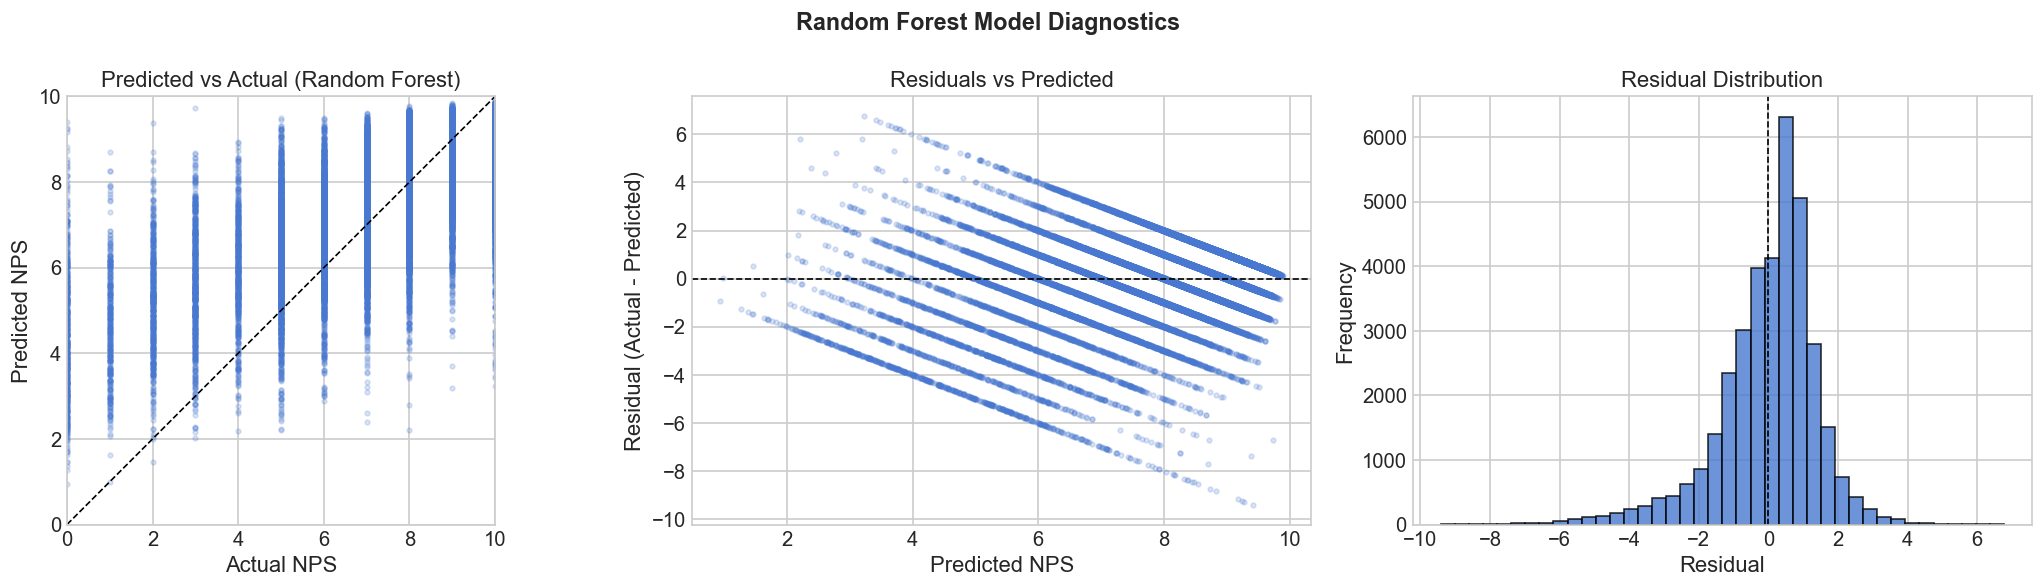

In [ ]:
rf_residuals = y_test - rf_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)


axes[0].scatter(y_test, rf_pred, alpha=0.2, s=8)

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())

axes[0].plot([min_val, max_val], [min_val, max_val],
             color='black', linestyle='--', linewidth=1)

axes[0].set_title("Predicted vs Actual (Random Forest)")
axes[0].set_xlabel("Actual NPS")
axes[0].set_ylabel("Predicted NPS")
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)
axes[0].set_aspect('equal', adjustable='box')

axes[1].scatter(rf_pred, rf_residuals, alpha=0.2, s=8)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)

axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted NPS")
axes[1].set_ylabel("Residual (Actual - Predicted)")

axes[2].hist(rf_residuals, bins=40, edgecolor='black', alpha=0.8)

axes[2].axvline(0, color='black', linestyle='--', linewidth=1)

axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Frequency")

fig.suptitle("Random Forest Model Diagnostics", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [26]:
# 5-fold cross-validation on train set
print ('Running 5-fold CV on training set (RF)')
cv = KFold (n_splits=5, shuffle = True, random_state = RANDOM_STATE)
cv_scores = cross_val_score (rf_pipeline, X_train, y_train, scoring = 'r2', n_jobs = -1, cv = cv)

print (f'CV R^2 scores: {cv_scores.round(4)}')
print (f'Mean CV R^2: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Running 5-fold CV on training set (RF)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['question_on_board_the_train1_the_atmosphere_on_board'
 'question_on_board_the_train1_the_level_of_comfort_on_board'
 'question_on_board_the_train1_the_cleanliness_on_board_the_train'
 'question_on_board_the_train2_the_wi_fi_on_board']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['question_on_board_the_train1_the_atmosphere_on_board'
 'question_on_board_the_train1_the_level_of_comfort_on_board'
 'question_on_board_the_train1_the_cleanliness_on_board_the_train'
 'question_on_board_the_train2_the_wi_fi_on_board']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base

CV R^2 scores: [0.5594 0.5686 0.5601 0.5626 0.5558]
Mean CV R^2: 0.5613 ± 0.0042


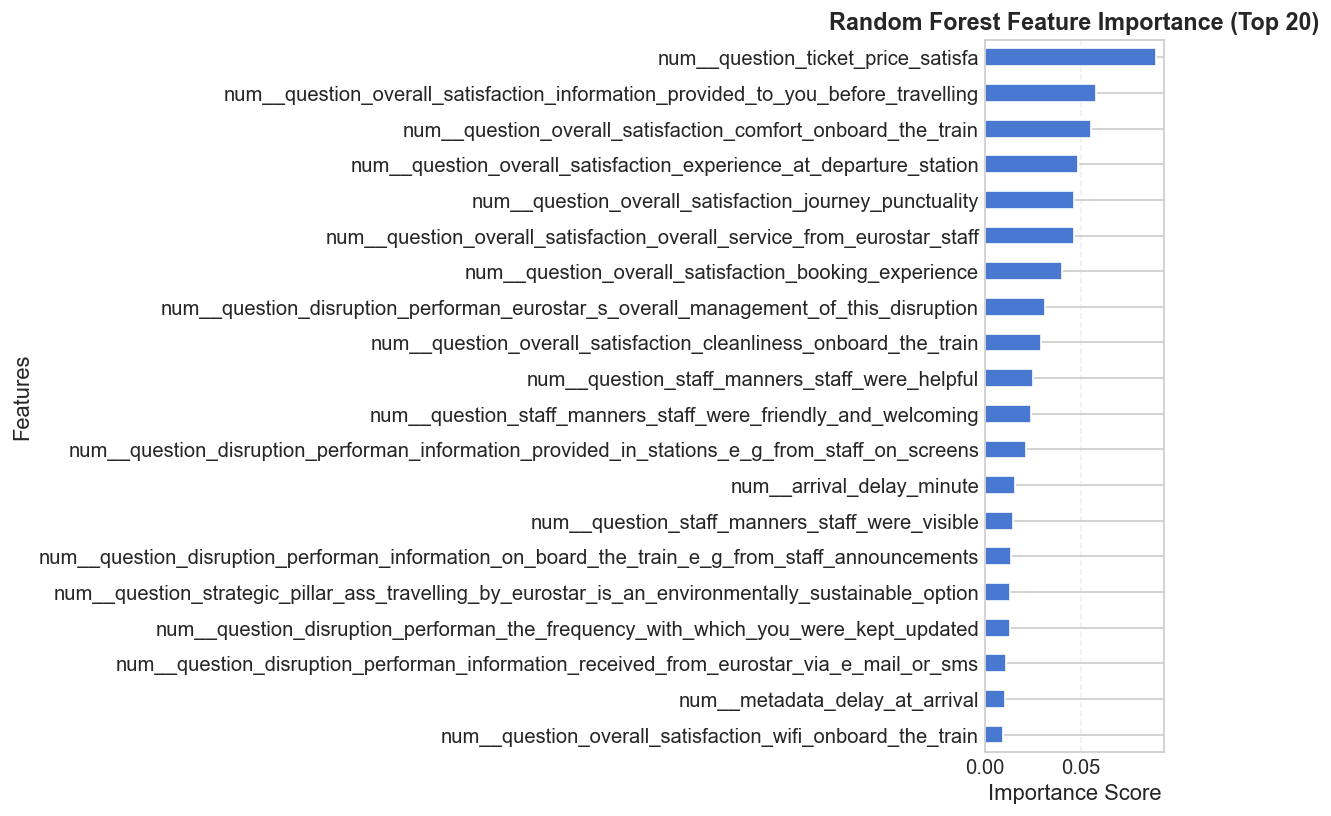

In [27]:
feature_names = preprocessor.get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

feat_imp = (
    pd.Series(importances, index=feature_names)
    .sort_values(ascending=True)   
)

top_n = 20
top_features = feat_imp.tail(top_n)

plt.figure(figsize=(10, 7), dpi=120)

top_features.plot(kind='barh')

plt.title('Random Forest Feature Importance (Top 20)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

## XGBoost

**Preprocess data for XGBoost**

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print (f'Processed train shape: {X_train_processed.shape}')
print (f'Processed test shape: {X_test_processed.shape}')
print (f'Total features after encoding: {len(feature_names)}')

Processed train shape: (143066, 496)
Processed test shape: (35767, 496)
Total features after encoding: 496


**Optuna bayesian tuning**

In [29]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'random_state': RANDOM_STATE,
        'tree_method': 'hist',
        'n_jobs': -1
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X_train_processed, y_train,
                             cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print('Best RMSE:', study.best_value)
print('Best params:', study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Exception ignored in: <function ResourceTracker.__del__ at 0x1073e9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1054b1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1056b9bc0>
Traceback (most recent call last

Best RMSE: 1.358908008831932
Best params: {'n_estimators': 1250, 'max_depth': 8, 'learning_rate': 0.014518182499732024, 'subsample': 0.6369679966813397, 'colsample_bytree': 0.745258409018119, 'min_child_weight': 10, 'gamma': 2.774467990477663, 'reg_alpha': 0.027197351957032656}


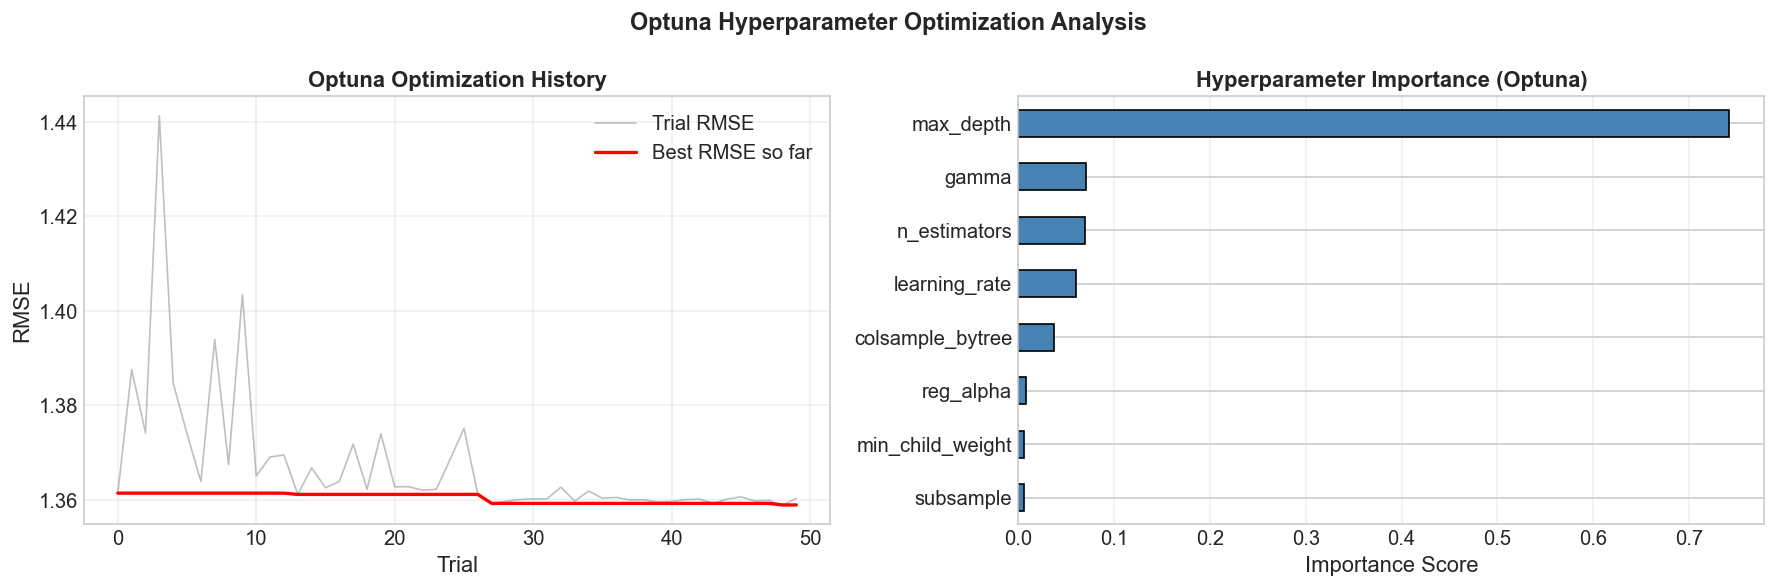

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=120)

trial_values = np.array([t.value for t in study.trials if t.value is not None])

axes[0].plot(
    trial_values,
    color='gray',
    linewidth=1,
    alpha=0.5,
    label='Trial RMSE'
)

axes[0].plot(
    pd.Series(trial_values).cummin(),
    color='red',
    linewidth=2,
    label='Best RMSE so far'
)

axes[0].set_title('Optuna Optimization History', fontweight='bold')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('RMSE')
axes[0].grid(alpha=0.3)
axes[0].legend()

try:
    param_imp = optuna.importance.get_param_importances(study)

    imp_series = (
        pd.Series(param_imp)
        .sort_values(ascending=True)
    )

    imp_series.plot(
        kind='barh',
        ax=axes[1],
        color='steelblue',
        edgecolor='black'
    )

    axes[1].set_title('Hyperparameter Importance (Optuna)', fontweight='bold')
    axes[1].set_xlabel('Importance Score')
    axes[1].grid(axis='x', alpha=0.3)

except Exception:
    axes[1].text(
        0.5, 0.5,
        'Hyperparameter importance\nnot available',
        ha='center',
        va='center',
        fontsize=11
    )
    axes[1].set_axis_off()

plt.suptitle('Optuna Hyperparameter Optimization Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Final XGBoost

In [31]:
best_params = study.best_params
best_params['random_state'] = RANDOM_STATE
best_params['tree_method'] = 'hist'
best_params['n_jobs'] = -1

xgb_model = XGBRegressor(**best_params)
xgb_model.fit(X_train_processed, y_train)

xgb_pred = xgb_model.predict(X_test_processed)
results.append(evaluate("XGBoost (Optuna-tuned)", y_test, xgb_pred))

Exception ignored in: <function ResourceTracker.__del__ at 0x105d39bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106f19bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


----------------------------------------
XGBoost (Optuna-tuned)
----------------------------------------
MAE: 0.9854 (avg error in NPS)
RMSE: 1.3628
R^2: 0.6170 (61.7% of variance explained)


**Evaluate**

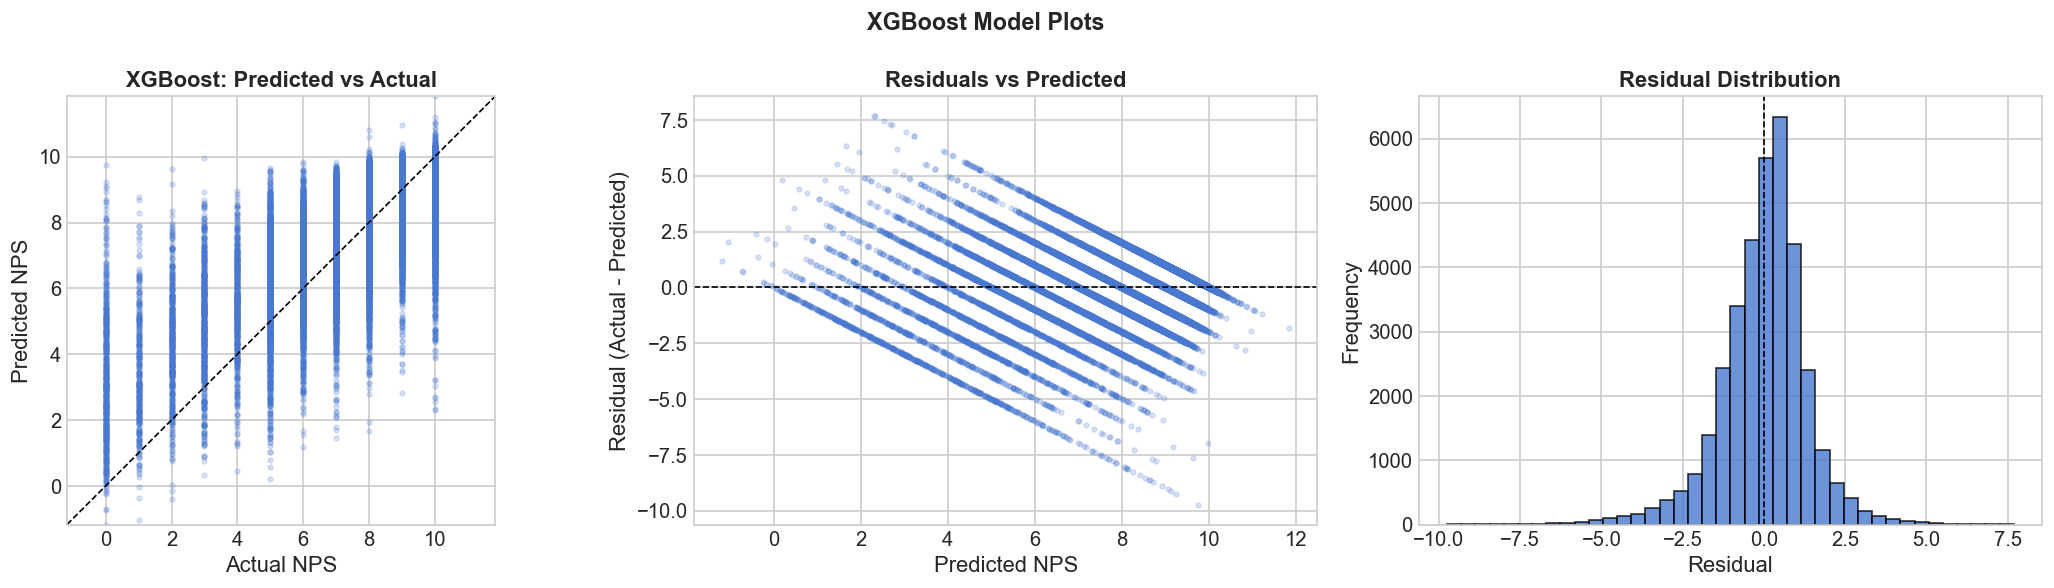

In [32]:
xgb_residuals = y_test.values - xgb_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

axes[0].scatter(y_test, xgb_pred, alpha=0.2, s=8)

min_val = min(y_test.min(), xgb_pred.min())
max_val = max(y_test.max(), xgb_pred.max())

axes[0].plot([min_val, max_val], [min_val, max_val],
             color='black', linestyle='--', linewidth=1)

axes[0].set_title("XGBoost: Predicted vs Actual", fontweight='bold')
axes[0].set_xlabel("Actual NPS")
axes[0].set_ylabel("Predicted NPS")
axes[0].set_xlim(min_val, max_val)
axes[0].set_ylim(min_val, max_val)
axes[0].set_aspect('equal', adjustable='box')

axes[1].scatter(xgb_pred, xgb_residuals, alpha=0.2, s=8)

axes[1].axhline(0, color='black', linestyle='--', linewidth=1)

axes[1].set_title("Residuals vs Predicted", fontweight='bold')
axes[1].set_xlabel("Predicted NPS")
axes[1].set_ylabel("Residual (Actual - Predicted)")

axes[2].hist(xgb_residuals, bins=40, edgecolor='black', alpha=0.8)

axes[2].axvline(0, color='black', linestyle='--', linewidth=1)

axes[2].set_title("Residual Distribution", fontweight='bold')
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Frequency")

fig.suptitle("XGBoost Model Plots", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Model comparison

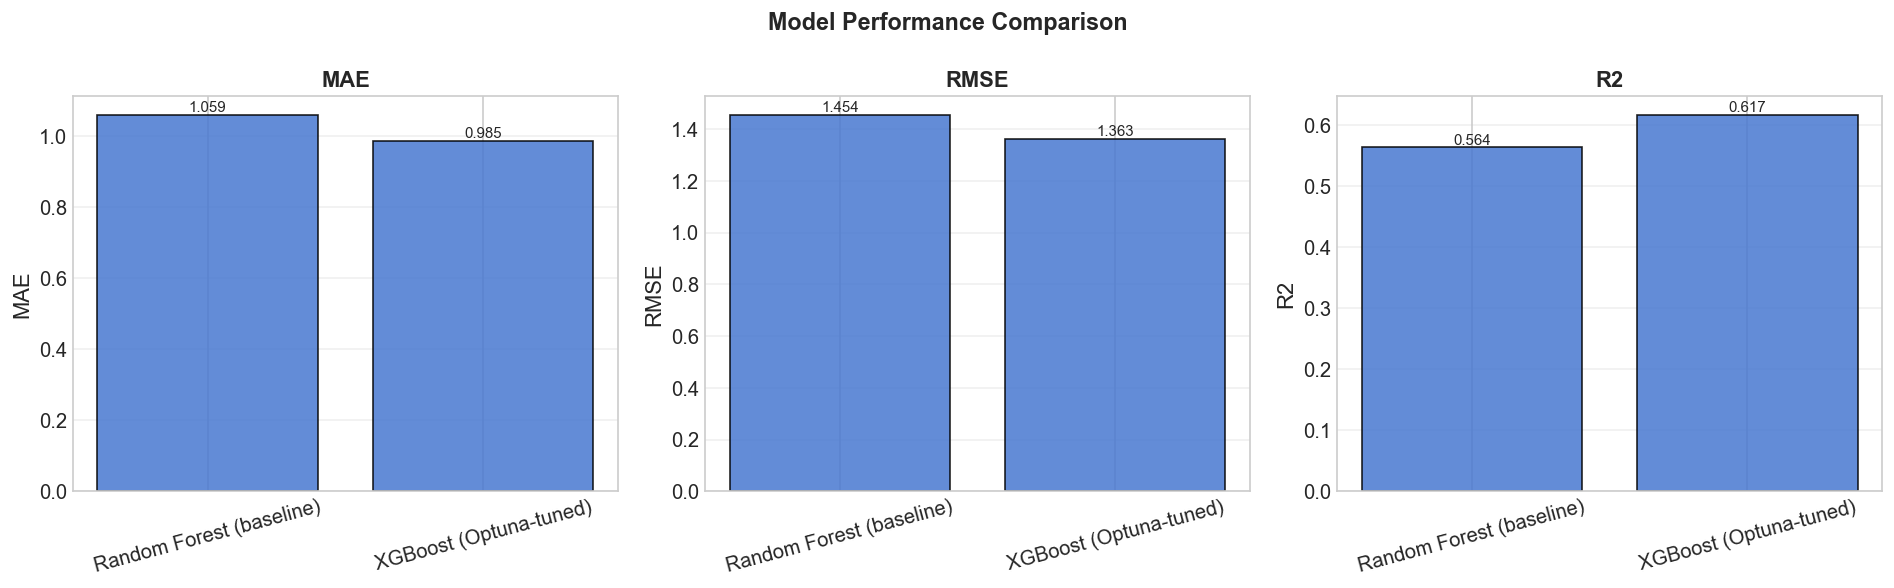

In [33]:
results_df = pd.DataFrame(results).set_index('model')

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=120)

metrics = ['MAE', 'RMSE', 'R2']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(
        results_df.index,
        results_df[metric],
        edgecolor='black',
        alpha=0.85
    )

    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', alpha=0.3)

    # value labels
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
improvement = results_df.loc['XGBoost (Optuna-tuned)'] - results_df.loc['Random Forest (baseline)']

print("\nXGBoost improvement over Random Forest:")
print("--------------------------------------")

print(f"MAE:  {improvement['MAE']:+.4f}")
print(f"RMSE: {improvement['RMSE']:+.4f}")
print(f"R²:   {improvement['R2']:+.4f}")


XGBoost improvement over Random Forest:
--------------------------------------
MAE:  -0.0736
RMSE: -0.0909
R²:   +0.0528


## SHAP

In [95]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_processed)
print (f'SHAP values computed. Shape: {shap_values.shape}')
print (f'Expected value (baseline prediction): {explainer.expected_value:.4f}')

SHAP values computed. Shape: (35767, 496)
Expected value (baseline prediction): 8.0697


**Global Importance**

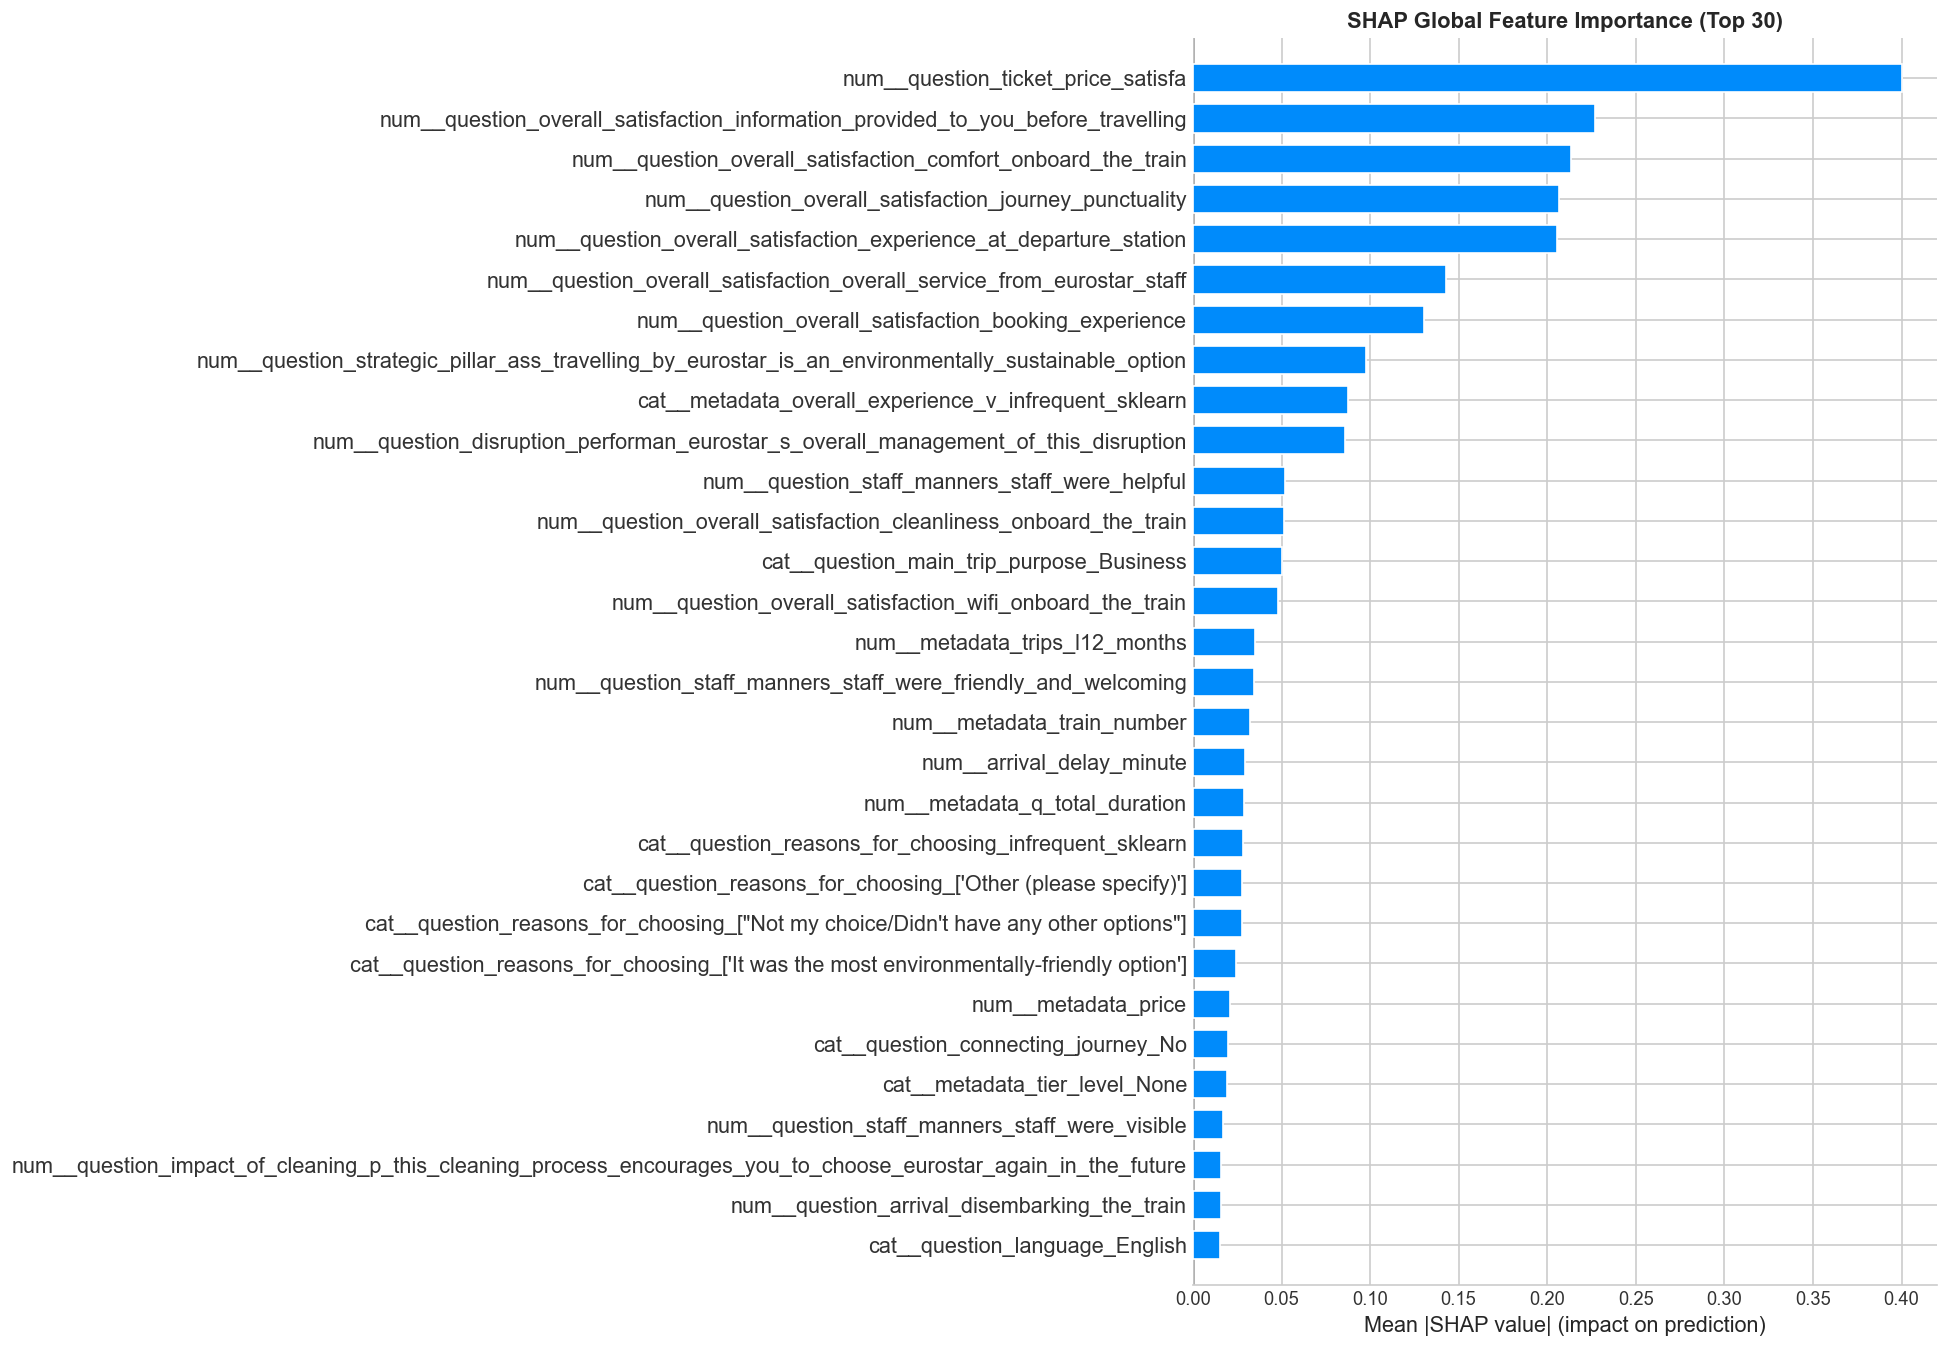

In [36]:
plt.figure(figsize=(10, 7), dpi=120)

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=30,
    show=False
)

plt.title("SHAP Global Feature Importance (Top 30)", fontweight="bold")
plt.xlabel("Mean |SHAP value| (impact on prediction)")
plt.tight_layout()
plt.show()

**Beeswarm plot**

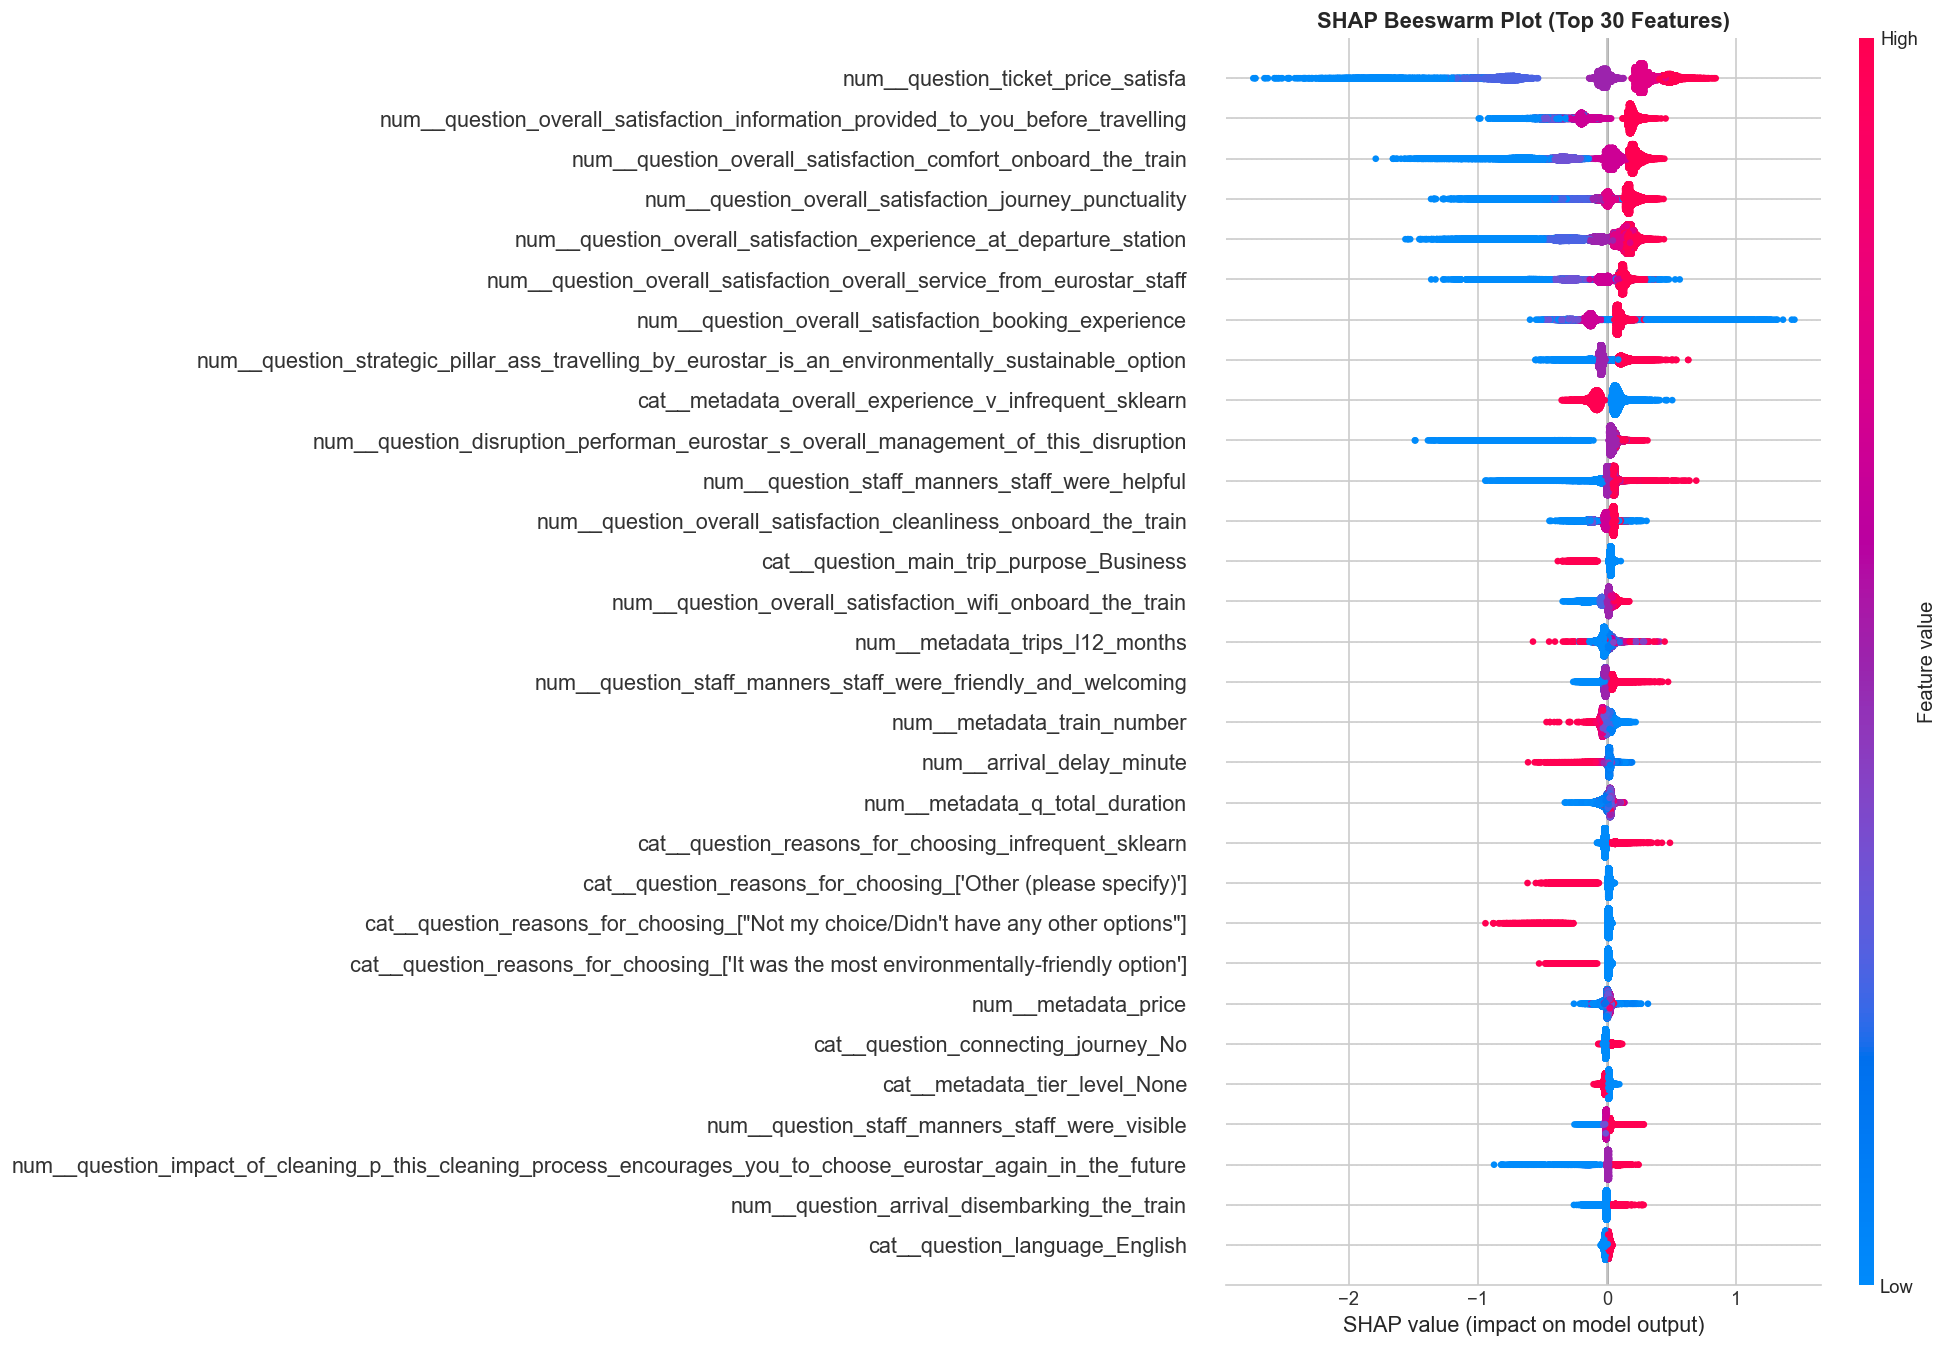

In [37]:
plt.figure(figsize=(10, 7), dpi=120)

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    max_display=30,
    show=False
)

plt.title("SHAP Beeswarm Plot (Top 30 Features)", fontweight="bold")
plt.tight_layout()
plt.show()

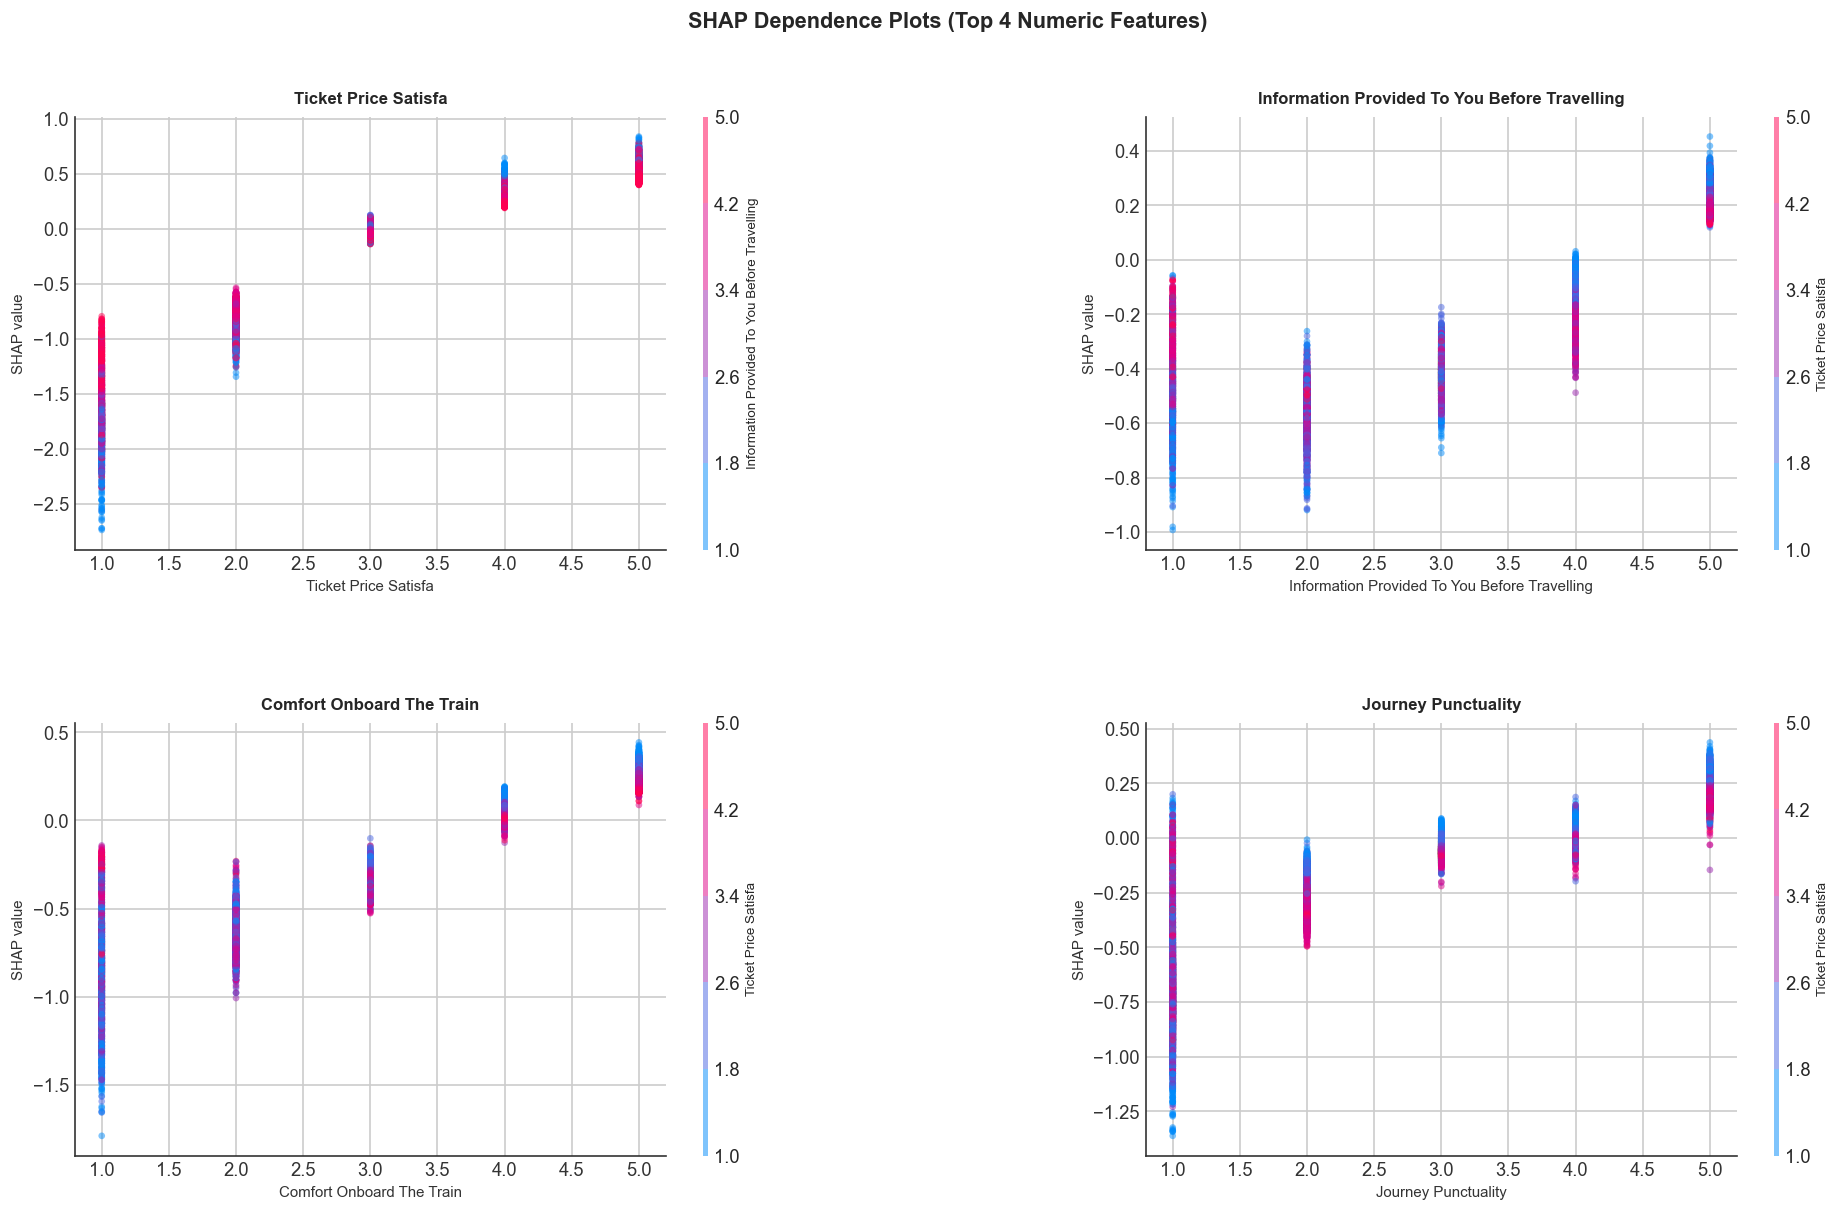

In [38]:
importance_series = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names)
top_numeric = (
    importance_series[importance_series.index.str.startswith("num__")]
    .sort_values(ascending=False)
    .head(4)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi = 120)
fig.patch.set_facecolor("white")

for ax, feat in zip(axes.flatten(), top_numeric.index):
    feat_idx = list(feature_names).index(feat)
    shap.dependence_plot(
        feat_idx, shap_values, X_test_processed,
        feature_names=feature_names, ax=ax, show=False,
        dot_size=16, alpha=0.5
    )
    short = feat.replace("num__", "").replace("question_overall_satisfaction_", "").replace("question_", "").replace("_", " ").title()
    ax.set_title(short, fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel(short, fontsize=9)
    ax.set_ylabel("SHAP value", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    cb_ax = fig.axes[-1]  
    cb_ax.set_ylabel(
        cb_ax.get_ylabel().replace("num__", "").replace("question_overall_satisfaction_", "").replace("question_", "").replace("_", " ").title(),
        fontsize=8
    )

plt.suptitle("SHAP Dependence Plots (Top 4 Numeric Features)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.45)
plt.show()

Lowest predicted NPS: -1.18 (actual: 0)


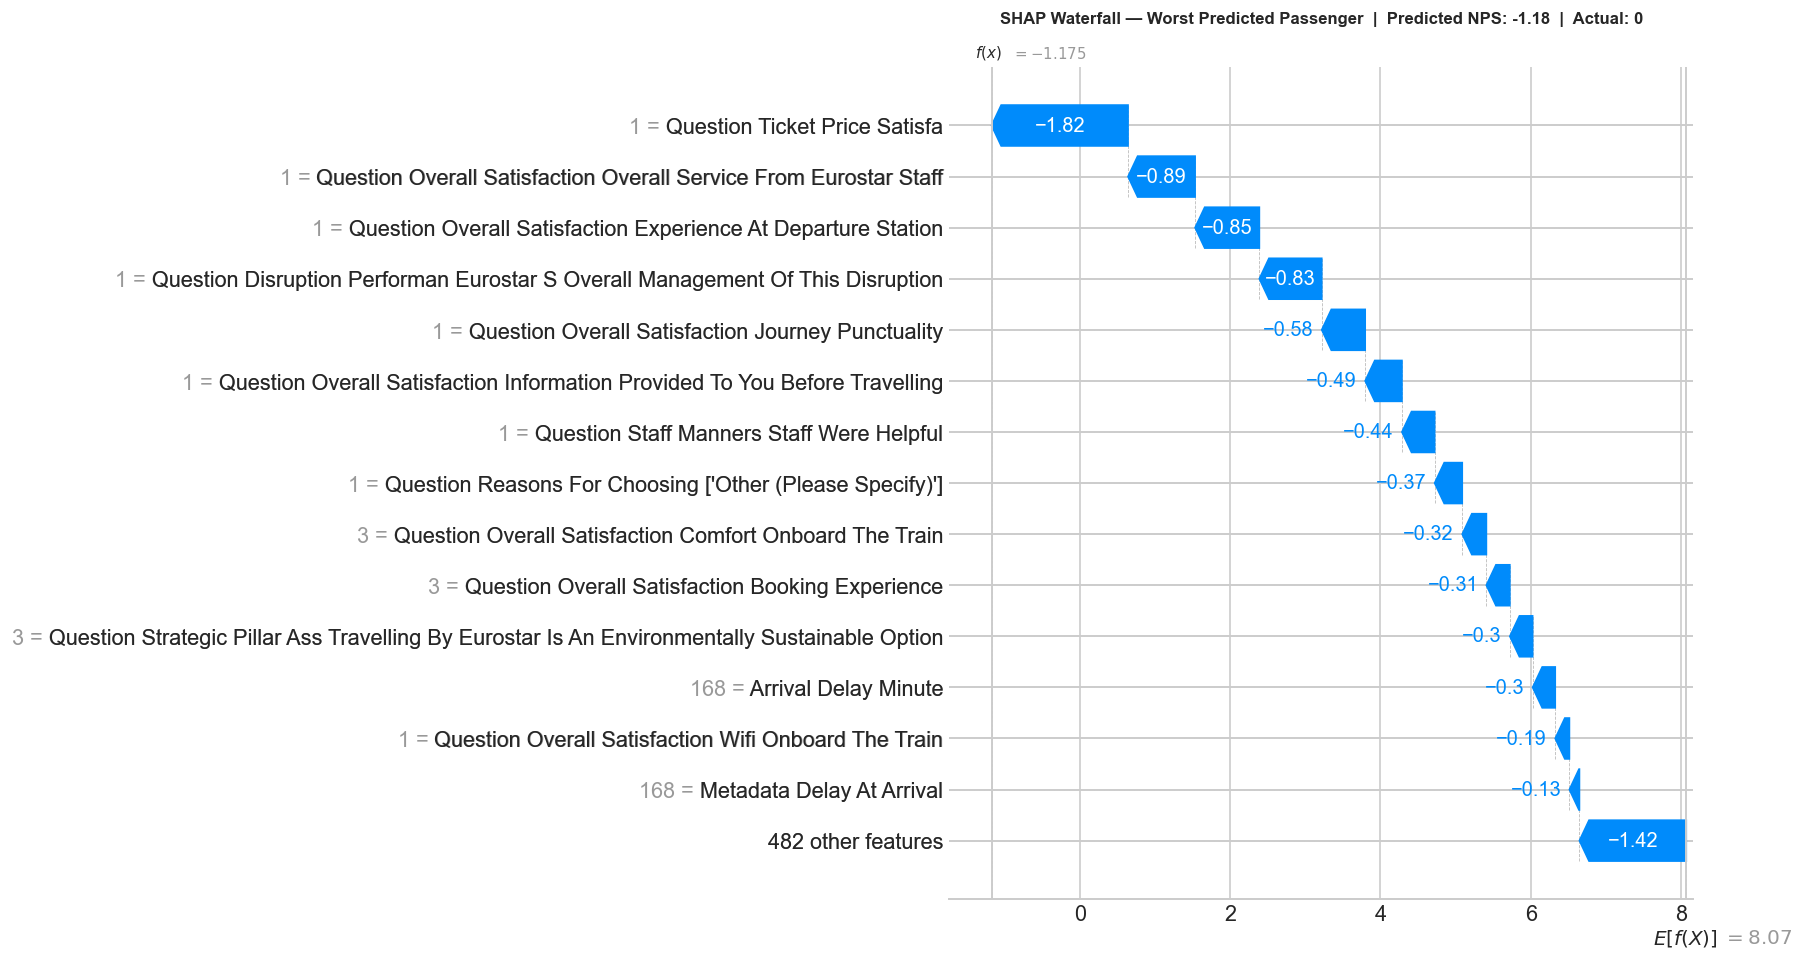

In [39]:
# waterfall
# worst predicted NPS
worst_idx = np.argmin(xgb_pred)
pred_val = xgb_pred[worst_idx]
actual_val = y_test.values[worst_idx]

print(f"Lowest predicted NPS: {pred_val:.2f} (actual: {actual_val:.0f})")

shap_explanation = shap.Explanation(
    values=shap_values[worst_idx],
    base_values=explainer.expected_value,
    data=X_test_processed[worst_idx],
    feature_names=[f.replace("num__", "").replace("cat__", "").replace("_", " ").title() for f in feature_names]
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, max_display=15, show=False)

ax = plt.gca()
ax.set_title(
    f"SHAP Waterfall — Worst Predicted Passenger  |  Predicted NPS: {pred_val:.2f}  |  Actual: {actual_val:.0f}",
    fontsize=10, fontweight="bold", pad=12
)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# create full SHAP importance df
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

# filter just operational features
operational_keywords = [
    'restriction', 'pm_', 'cm_', 'clean_', 'delay', 
    'arrival_delay', 'early_journey', 'n_trainsets'
]

op_features = shap_importance[
    shap_importance['feature'].str.contains('|'.join(operational_keywords))
]
print(op_features.head(20))
print(f'\nHighest operational feature rank: {op_features.index[0]}')

In [ ]:
# export
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs (shap_values).mean(axis = 0),
    'mean_shap': shap_values.mean(axis = 0),
    'std_shap': shap_values.std(axis = 0)
}).sort_values ('mean_abs_shap', ascending = False)

print (f'Top 15 NPS drivers:')
print (importance_df.head(15).to_string(index = False))

## Truly Operational

In [99]:
truly_operational_cols = [
    # Train maintenance
    'restriction_open_Toilets', 'restriction_open_Air Conditioning',
    'restriction_open_Refrigeration', 'restriction_open_Windows',
    'restriction_open_WiFi', 'restriction_open_Heating',
    'total restrictions',
    'restriction_days_Toilets', 'restriction_days_Air Conditioning',
    'restriction_days_Refrigeration', 'restriction_days_Windows',
    'restriction_days_WiFi', 'restriction_days_Heating',
    'longest restriction',
    # Preventive maintenance
    'pm_days_since_catering', 'pm_days_since_toilet', 'pm_days_since_climate',
    'pm_days_since_interior', 'pm_days_since_reliability', 'pm_days_since_comms',
    'pm_days_since_wifi', 'average days since last exams',
    'pm_has_prior_catering', 'pm_has_prior_toilet', 'pm_has_prior_climate',
    'pm_has_prior_interior', 'pm_has_prior_reliability', 'pm_has_prior_comms',
    'pm_has_prior_wifi',
    # Corrective maintenance / faults
    'cm_open_climate', 'cm_open_wifi', 'cm_open_interior', 'cm_open_catering',
    'cm_open_toilet', 'cm_open_cleaning', 'total open faults',
    # Cleaning
    'clean_score_routine', 'clean_hours_since_routine',
    'clean_score_deep', 'clean_days_since_deep',
    'last_clean_score', 'hours_since_last_clean',
    'clean_has_prior_routine', 'clean_has_prior_deep',
    # Journey/delay
    'early_journey_delay_minute', 'arrival_delay_minute',
    'compensation_liability_evouchers', 'compensation_liability_cash',
    'delay_cause_id',
    # Train metadata
    'metadata_departure_hour',
    'metadata_price', 'metadata_trips_l12_months',
    'metadata_class_of_service', 'metadata_route', 'metadata_train_type',
    'n_trainsets', 'equipment_type', 'train_service', 'route_type',
]

In [100]:
X_truly_op = X[[c for c in truly_operational_cols if c in X.columns]]
print(f'Truly operational features: {X_truly_op.shape[1]}')

Truly operational features: 59


In [101]:
categorical_cols_trop = X_truly_op.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols_trop     = X_truly_op.select_dtypes(include=['int64', 'float64', 'Int8', 'Int16', 'Int32', 'Int64']).columns.tolist()
print(f'Numeric: {len(numeric_cols_trop)} | Categorical: {len(categorical_cols_trop)}')

Numeric: 51 | Categorical: 8


In [102]:
y_bin = pd.cut(y, bins=[-1, 6, 8, 10], labels=['detractor', 'passive', 'promoter'])
X_train_trop, X_test_trop, y_train_trop, y_test_trop = train_test_split(
    X_truly_op, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bin
)

print (f'Train: {X_train_trop.shape[0]:,} rows | Test: {X_test_trop.shape[0]:,} rows')
print (f'Train NPS mean: {y_train_trop.mean():.3f}| Test NPS mean: {y_test_trop.mean():.3f}')
print (f'Train NPS std {y_train_trop.std():.3f} | Test NPS std: {y_test_trop.std():.3f}')

Train: 143,066 rows | Test: 35,767 rows
Train NPS mean: 8.070| Test NPS mean: 8.061
Train NPS std 2.183 | Test NPS std: 2.202


In [103]:
preprocessor_trop = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols_trop),
    ('cat', categorical_transformer, categorical_cols_trop),
])
X_train_trop_proc = preprocessor_trop.fit_transform(X_train_trop)
X_test_trop_proc  = preprocessor_trop.transform(X_test_trop)

In [104]:
feature_names_trop = preprocessor_trop.get_feature_names_out()

print (f'Processed train shape: {X_train_trop_proc.shape}')
print (f'Processed test shape: {X_test_trop_proc.shape}')
print (f'Total features after encoding: {len(feature_names_trop)}')

Processed train shape: (143066, 97)
Processed test shape: (35767, 97)
Total features after encoding: 97


In [105]:
best_params_trop = study.best_params
best_params_trop['random_state'] = RANDOM_STATE
best_params_trop['tree_method'] = 'hist'
best_params_trop['n_jobs'] = -1

xgb_model_trop = XGBRegressor(**best_params_trop)
xgb_model_trop.fit(X_train_trop_proc, y_train_trop)

xgb_pred_trop = xgb_model_trop.predict(X_test_trop_proc)
results.append(evaluate("XGBoost (Optuna-tuned) (Truly Operational)", y_test_trop, xgb_pred_trop))

----------------------------------------
XGBoost (Optuna-tuned) (Truly Operational)
----------------------------------------
MAE: 1.5058 (avg error in NPS)
RMSE: 2.0433
R^2: 0.1389 (13.9% of variance explained)


In [106]:
explainer_trop = shap.TreeExplainer(xgb_model_trop)

shap_values_trop = explainer_trop.shap_values(X_test_trop_proc)
print (f'SHAP values computed. Shape: {shap_values_trop.shape}')
print (f'Expected value (baseline prediction): {explainer_trop.expected_value:.4f}')

SHAP values computed. Shape: (35767, 97)
Expected value (baseline prediction): 8.0705


In [107]:
feature_names_trop = preprocessor_trop.get_feature_names_out()
print(f'Feature names: {len(feature_names_trop)} | SHAP values: {shap_values_trop.shape[1]}')

Feature names: 97 | SHAP values: 97


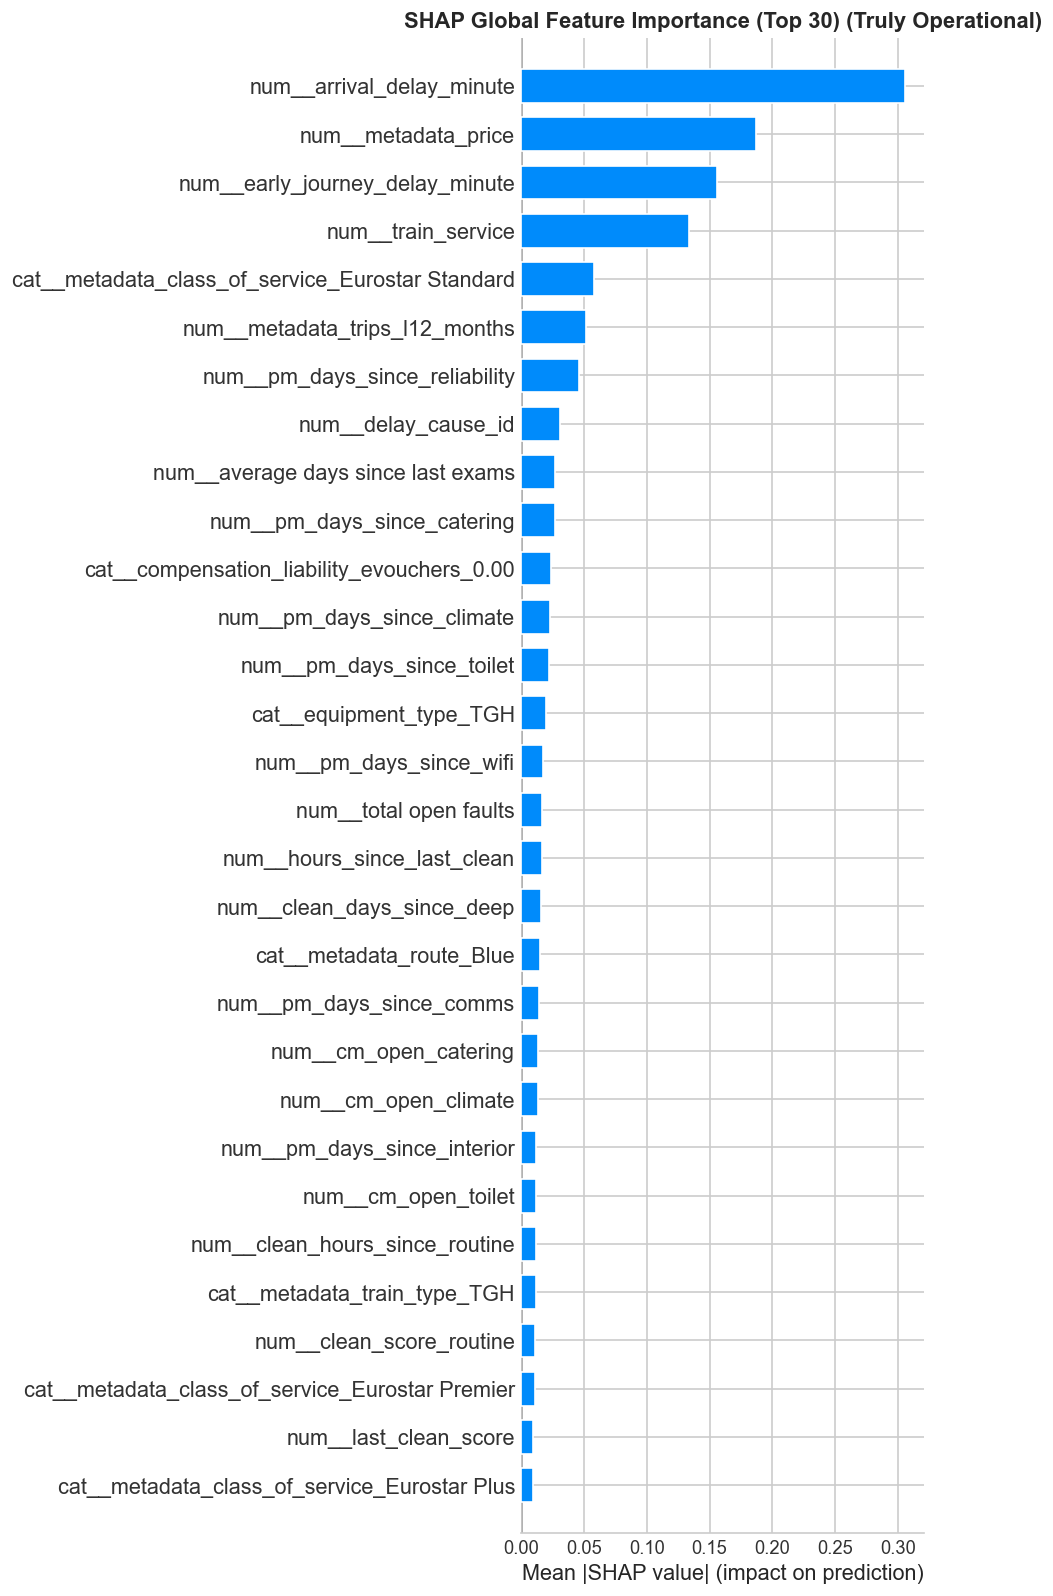

In [108]:
# global importance
plt.figure(figsize=(10, 7), dpi=120)

shap.summary_plot(
    shap_values_trop,
    X_test_trop_proc,
    feature_names=feature_names_trop,
    plot_type="bar",
    max_display=30,
    show=False
)

plt.title("SHAP Global Feature Importance (Top 30) (Truly Operational)", fontweight="bold")
plt.xlabel("Mean |SHAP value| (impact on prediction)")
plt.tight_layout()
plt.show()

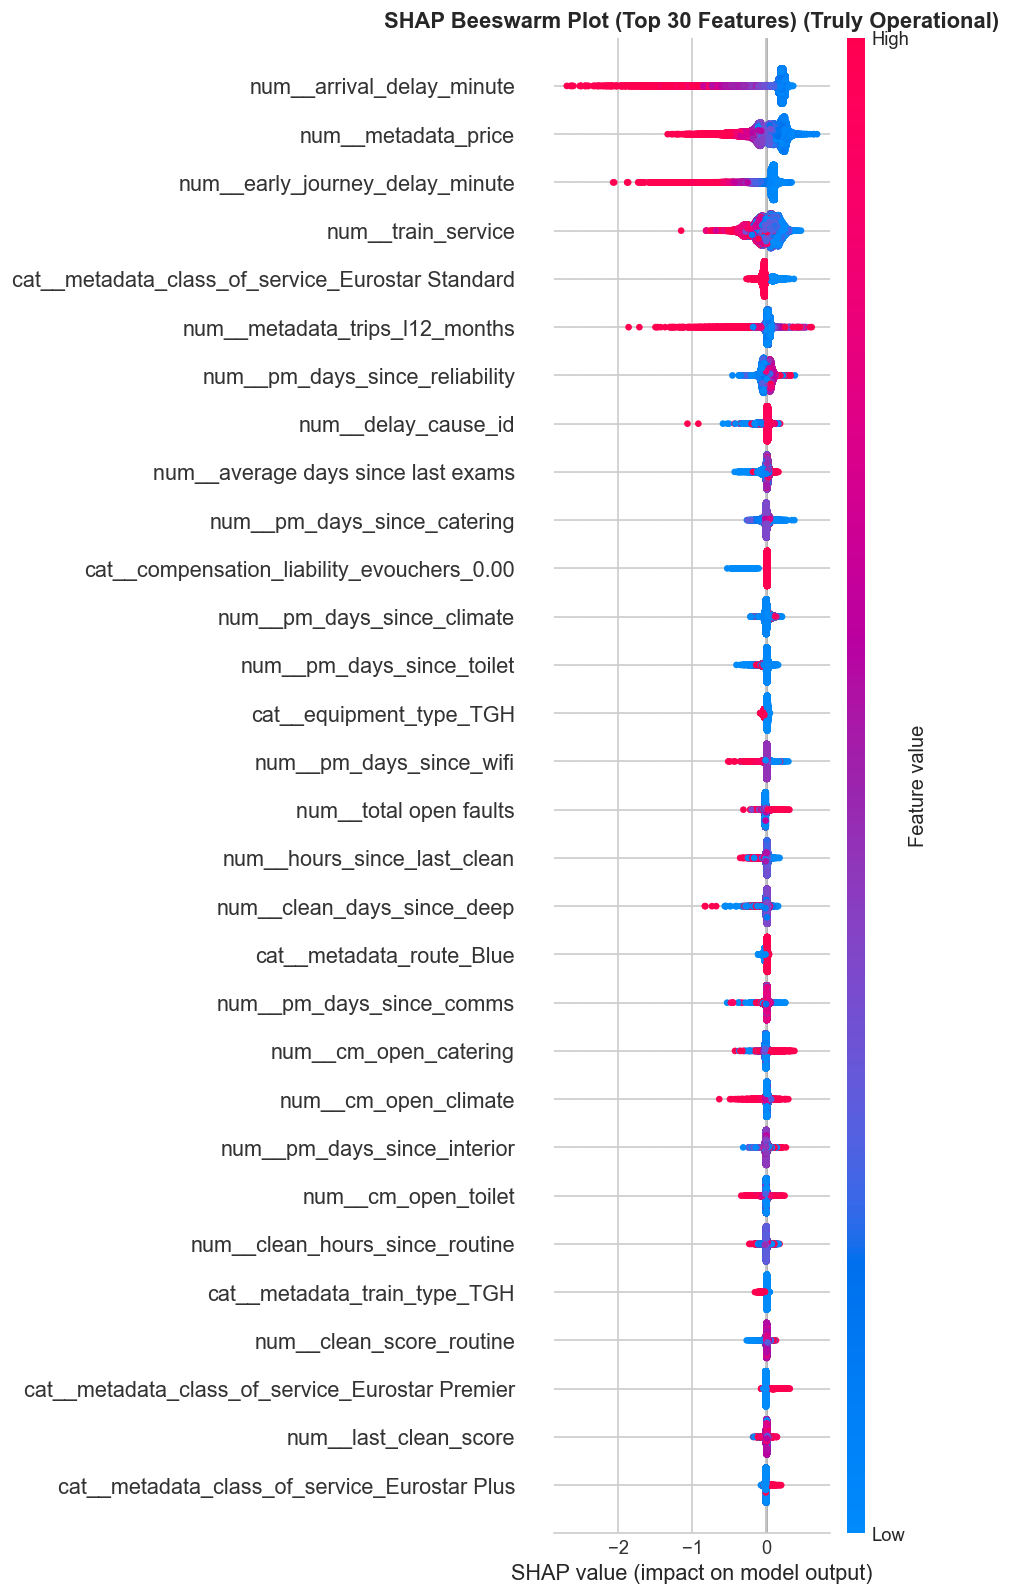

In [109]:
# beeswarm plot
plt.figure(figsize=(10, 7), dpi=120)

shap.summary_plot(
    shap_values_trop,
    X_test_trop_proc,
    feature_names=feature_names_trop,
    max_display=30,
    show=False
)

plt.title("SHAP Beeswarm Plot (Top 30 Features) (Truly Operational)", fontweight="bold")
plt.tight_layout()
plt.show()

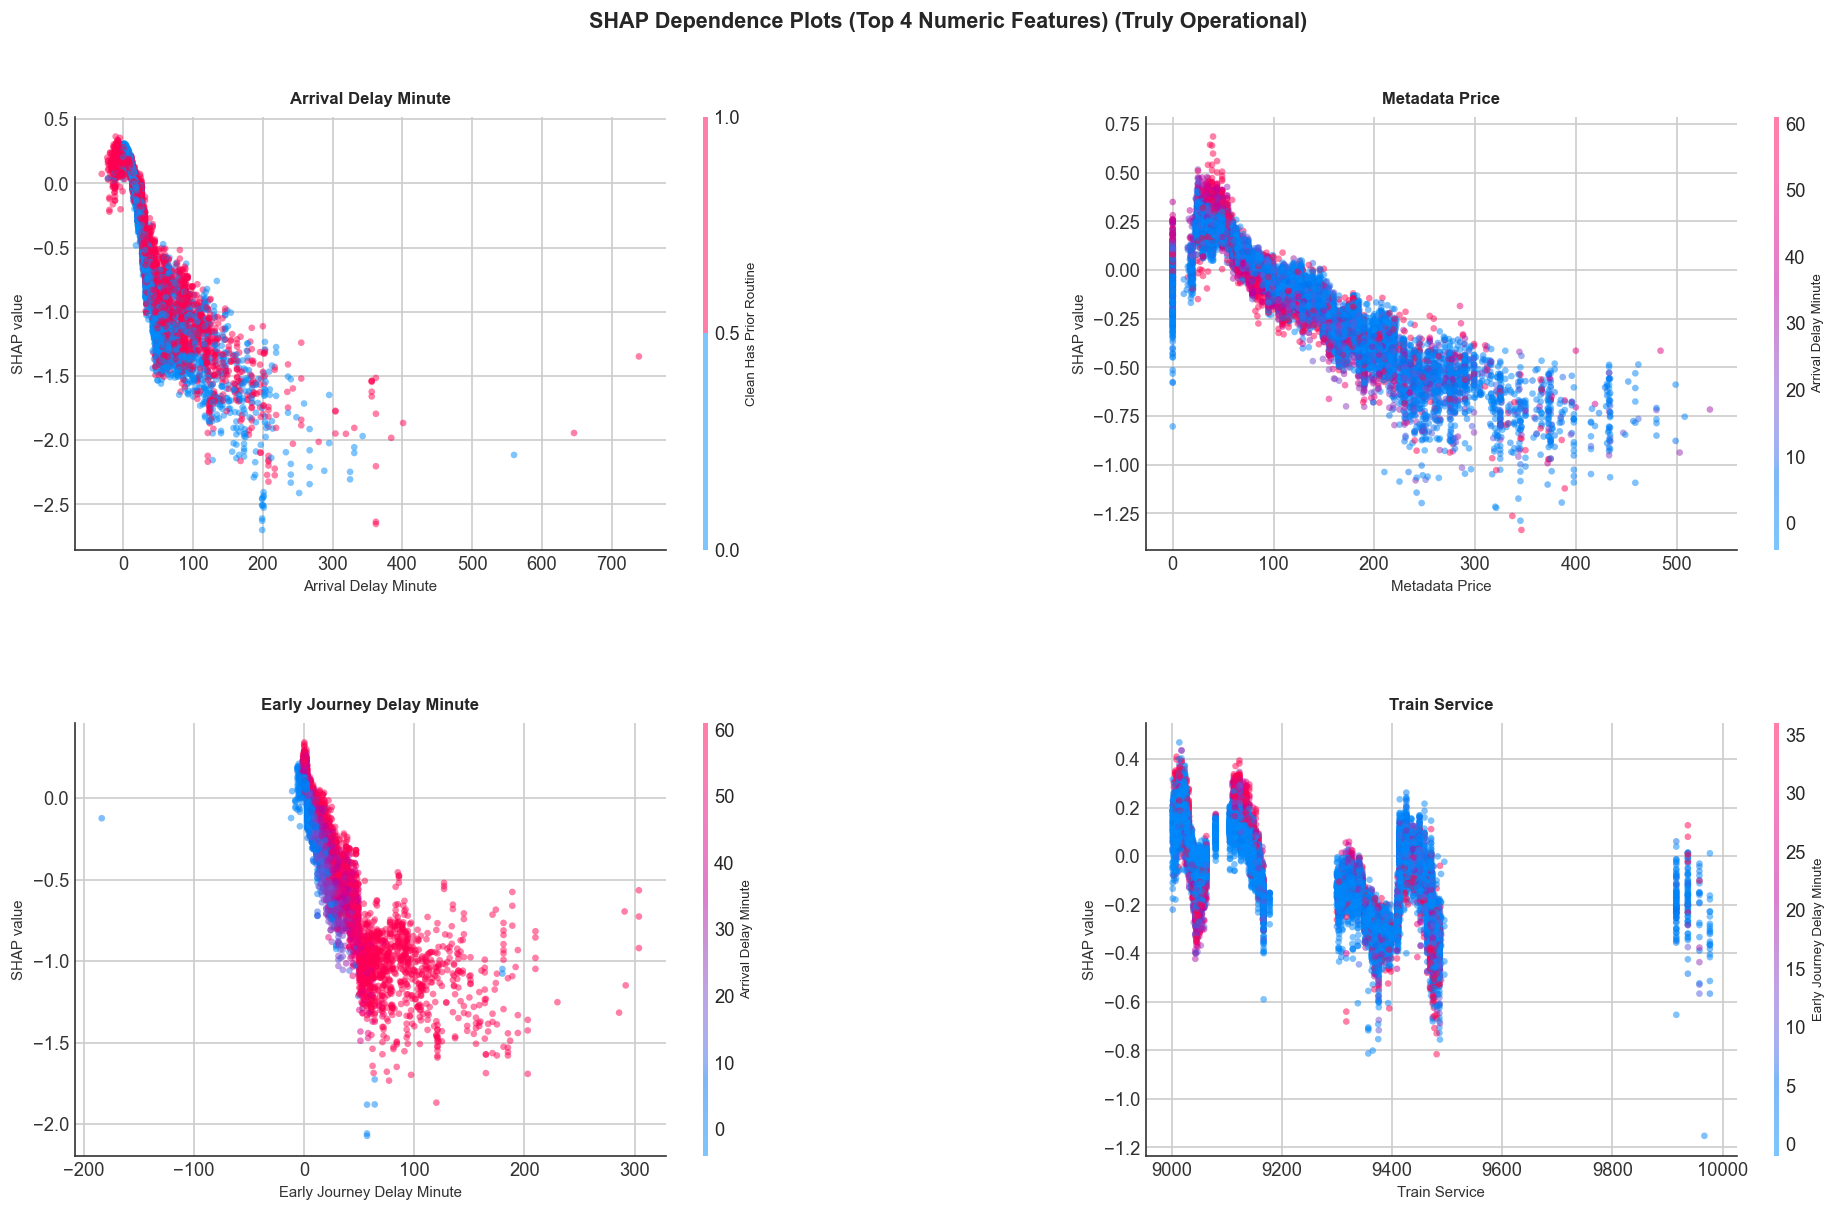

In [110]:
# dependence plots
# top 4 numeric features by mean |SHAP|
importance_series_trop = pd.Series(np.abs(shap_values_trop).mean(axis=0), index=feature_names_trop)
top_numeric_trop = (
    importance_series_trop[importance_series_trop.index.str.startswith("num__")]
    .sort_values(ascending=False)
    .head(4)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi = 120)
fig.patch.set_facecolor("white")

for ax, feat in zip(axes.flatten(), top_numeric_trop.index):
    feat_idx_trop = list(feature_names_trop).index(feat)
    shap.dependence_plot(
        feat_idx_trop, shap_values_trop, X_test_trop_proc,
        feature_names=feature_names_trop, ax=ax, show=False,
        dot_size=16, alpha=0.5
    )
    short = feat.replace("num__", "").replace("question_overall_satisfaction_", "").replace("question_", "").replace("_", " ").title()
    ax.set_title(short, fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel(short, fontsize=9)
    ax.set_ylabel("SHAP value", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    cb_ax = fig.axes[-1]  
    cb_ax.set_ylabel(
        cb_ax.get_ylabel().replace("num__", "").replace("question_overall_satisfaction_", "").replace("question_", "").replace("_", " ").title(),
        fontsize=8
    )

plt.suptitle("SHAP Dependence Plots (Top 4 Numeric Features) (Truly Operational)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.45)
plt.show()